# Molecular Feature Difficulty Analysis — DDP runs (`gecko_new`, `gecko_new_mixed_augment`)

Explores which molecular features make test-set compounds harder to predict, i.e. not
recovered within the **top-K** predictions.

Differences from `feature_difficulty_analysis.ipynb`:

* **Data layout.** These runs come straight off the cluster output tree,
  `data/experiments/<experiment>/<date>/<jobid>-<name>/preds/`, rather than a flat
  `data/new_experiments/expN/` directory.
* **DDP shards.** Predictions are written per rank *and* per per-rank batch
  (`dev_pred_r<rank>_<batch>.pkl`), so the shards are re-interleaved back into the
  original `DistributedSampler` order and the padding duplicates at the tail are dropped.
* **Real top-K.** 100 candidates were generated per molecule (the earlier runs had 10),
  and candidates are ranked by **occurrence count** among those 100 — the same ranking
  `K_ACC_Collection.update()` uses. Top-K therefore means top-K *ranked* candidates, not
  "the first K sampled".
* **Any K.** `TOP_K` in the config cell drives every hit/miss split, plot title and output
  filename in the notebook — set it and re-run.
* Tanimoto-similarity sections are omitted.

Uses ATMOMACCS v5 fingerprints, standard MACCS keys, and RDKit molecular descriptors, then
K-means clusters each test set.

In [1]:
import sys, os, re, glob, time, warnings, pickle as pkl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, rdMolDescriptors, Draw
from rdkit.Chem.Draw import IPythonConsole
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy import stats

sys.path.insert(0, '../src')
from ATMOMACCS_no_binary import pyGenATMOKeys, pyGenATMOMACCS, pyGenMACCSKeys
from src.utils import is_valid

RDLogger.DisableLog('rdApp.*')
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
IPythonConsole.molSize = (350, 350)

PLOT_DPI = 150
fs = 11
plt.rcParams.update({'font.size': fs})
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif']

print('Setup complete.')

Setup complete.


## 0. Configuration

In [2]:
# Root of the cluster output tree that was copied down (checkpoints stripped).
EXP_BASE = 'data/experiments'

# The one knob: every hit/miss split, plot title and output filename below uses TOP_K.
TOP_K = 100

# Extra k values reported alongside TOP_K in the accuracy tables / curves.
# Values above the number of generated candidates are dropped automatically.
K_LIST = sorted({1, 3, 5, 10, 20, 50, 100, TOP_K})

HIT = f'hit_top{TOP_K}'   # column name used throughout

EXP_CONFIGS = {
    'Gecko (new)':                 dict(exp='gecko_new'),
    'Gecko (new) + mixed augment': dict(exp='gecko_new_mixed_augment'),
}

def slug(name):
    """Filesystem-safe version of an experiment label."""
    return re.sub(r'[^A-Za-z0-9]+', '_', name).strip('_')

print(f'TOP_K = {TOP_K}   (hit column: {HIT})')
print(f'k values reported: {K_LIST}')

TOP_K = 100   (hit column: hit_top100)
k values reported: [1, 3, 5, 10, 20, 50, 100]


## 1. Load experiment predictions (DDP-sharded)

`diffusion_model_spec2mol.test_step` writes one pickle per *rank* per *per-rank batch*:

```
preds/dev_pred_r<rank>_<batch>.pkl   # list[n_mols][n_candidates] of RDKit Mol
preds/dev_true_r<rank>_<batch>.pkl   # list[n_mols]               of RDKit Mol
```

Lightning wraps the test dataloader in `DistributedSampler(shuffle=False)`, which gives
rank *r* the strided global positions `r, r+W, r+2W, ...` (W = world size). So rank *r*'s
*j*-th sample (batches concatenated in order) is global position `r + W*j` — that is what
`_to_global_order` undoes.

`DistributedSampler` also pads the index list up to a multiple of W by repeating the first
`pad` indices (`pad < W`), so the last `pad` records are duplicates of the first `pad`.
`_strip_ddp_padding` finds and removes them; without that, the smallest molecules in the
test set would be double-counted.

In [3]:
_PRED_RE = re.compile(r'^(?P<prefix>.+)_r(?P<rank>\d+)_(?P<batch>\d+)\.pkl$')


def find_preds_dir(exp, base=EXP_BASE):
    """Locate <base>/<exp>/<date>/<jobid>-<name>/preds, erroring if it is not unique."""
    hits = sorted(glob.glob(os.path.join(base, exp, '*', '*', 'preds')))
    if not hits:
        raise FileNotFoundError(f'No preds/ directory under {os.path.join(base, exp)}')
    if len(hits) > 1:
        raise ValueError(f'{exp}: {len(hits)} candidate run directories, pass one explicitly:\n  '
                         + '\n  '.join(hits))
    return hits[0]


def _to_global_order(per_rank):
    """Interleave {rank: [samples in per-rank order]} back into DistributedSampler order."""
    world = len(per_rank)
    if sorted(per_rank) != list(range(world)):
        raise ValueError(f'Ranks are not contiguous 0..{world-1}: {sorted(per_rank)}')
    lens = {len(v) for v in per_rank.values()}
    if len(lens) != 1:
        raise ValueError(f'Ranks hold different numbers of samples: '
                         + str({r: len(v) for r, v in per_rank.items()}))
    n_per_rank = lens.pop()
    out = [None] * (world * n_per_rank)
    for r, samples in per_rank.items():
        for j, s in enumerate(samples):
            out[r + world * j] = s
    return out, world


def _strip_ddp_padding(records, world):
    """Drop the trailing pad < world records that DistributedSampler duplicated from the head.

    Compares canonical SMILES of the true molecules; returns the trimmed list and pad size.
    """
    smis = [Chem.MolToSmiles(r['true_mol']) for r in records]
    for pad in range(world - 1, 0, -1):
        if smis[-pad:] == smis[:pad]:
            return records[:-pad], pad
    return records, 0


def load_ddp_exp(exp, base=EXP_BASE, pred_prefix='dev_pred', true_prefix='dev_true',
                 preds_dir=None, verbose=True):
    """Load every rank/batch shard of a DDP run into one globally ordered record list."""
    d = preds_dir or find_preds_dir(exp, base)

    shards = {}   # rank -> {batch: filename}
    for f in os.listdir(d):
        m = _PRED_RE.match(f)
        if m and m.group('prefix') == pred_prefix:
            shards.setdefault(int(m.group('rank')), {})[int(m.group('batch'))] = f
    if not shards:
        raise FileNotFoundError(f'No {pred_prefix}_r*_*.pkl shards in {d}')

    per_rank = {}
    n_files = 0
    for rank, batches in shards.items():
        samples = []
        for b in sorted(batches):
            pf = batches[b]
            tf = pf.replace(pred_prefix, true_prefix, 1)
            with open(os.path.join(d, pf), 'rb') as fh:
                preds = pkl.load(fh)
            with open(os.path.join(d, tf), 'rb') as fh:
                trues = pkl.load(fh)
            if len(preds) != len(trues):
                raise ValueError(f'{pf}: {len(preds)} preds vs {len(trues)} trues')
            samples.extend({'true_mol': t, 'pred_mols': p, 'rank': rank, 'batch': b}
                           for p, t in zip(preds, trues))
            n_files += 2
        per_rank[rank] = samples

    records, world = _to_global_order(per_rank)
    n_raw = len(records)
    records, pad = _strip_ddp_padding(records, world)
    for i, r in enumerate(records):
        r['global_pos'] = i

    if verbose:
        n_cand = Counter(len(r['pred_mols']) for r in records)
        print(f'{exp}:')
        print(f'  dir            : {d}')
        print(f'  world size     : {world}   ({n_files} shard files)')
        print(f'  raw records    : {n_raw:,}  ->  {len(records):,} after dropping {pad} DDP padding duplicate(s)')
        print(f'  candidates/mol : {dict(n_cand)}')
    return records


experiments_records = {}
for exp_name, cfg in EXP_CONFIGS.items():
    print(f'=== {exp_name} ===')
    experiments_records[exp_name] = load_ddp_exp(**cfg)
    print()

=== Gecko (new) ===
gecko_new:
  dir            : data/experiments\gecko_new\2026-07-29\20413716-dev\preds
  world size     : 32   (128 shard files)
  raw records    : 7,552  ->  7,548 after dropping 4 DDP padding duplicate(s)
  candidates/mol : {100: 7548}

=== Gecko (new) + mixed augment ===
gecko_new_mixed_augment:
  dir            : data/experiments\gecko_new_mixed_augment\2026-07-30\20449604-dev\preds
  world size     : 32   (128 shard files)
  raw records    : 7,552  ->  7,548 after dropping 4 DDP padding duplicate(s)
  candidates/mol : {100: 7548}



In [4]:
# Sanity check: the test split is size-sorted, so global order should be (near) monotonic
# in heavy-atom count. A break at the very end would mean padding was not stripped.
for exp_name, records in experiments_records.items():
    sizes = np.array([r['true_mol'].GetNumAtoms() for r in records])
    breaks = np.where(np.diff(sizes) < 0)[0]
    dupes = Counter(Chem.MolToSmiles(r['true_mol']) for r in records)
    n_dupe = sum(c - 1 for c in dupes.values())
    print(f'{exp_name}: n={len(records):,}  heavy atoms {sizes.min()}-{sizes.max()}  '
          f'order breaks={len(breaks)} (last at {breaks[-1] if len(breaks) else "-"})  '
          f'unique true SMILES={len(dupes):,} ({n_dupe} repeated test entries kept)')

Gecko (new): n=7,548  heavy atoms 1-82  order breaks=6 (last at 6497)  unique true SMILES=7,318 (230 repeated test entries kept)
Gecko (new) + mixed augment: n=7,548  heavy atoms 1-82  order breaks=6 (last at 6497)  unique true SMILES=7,318 (230 repeated test entries kept)


## 2. Rank candidates by occurrence → real top-K

Replicates `src/metrics/diffms_metrics.py::K_ACC_Collection.update()` exactly:

1. drop invalid candidates (`is_valid`),
2. convert the rest to InChI,
3. rank the unique InChIs by **how often** they were generated (`Counter.most_common()`),
4. a molecule is a top-k hit if the true InChI is among the first *k* of that ranking.

The ranking is computed once and cached on each record, so changing `TOP_K` afterwards only
requires re-running the hit-flag cell below, not this one (~1 min per experiment).

In [5]:
def rank_candidates(pred_mols):
    """Unique candidate InChIs ranked by generation frequency, plus their counts."""
    inchis = [Chem.MolToInchi(mol) for mol in pred_mols if is_valid(mol)]
    ranked = Counter(inchis).most_common()
    return [i for i, _ in ranked], [c for _, c in ranked]


for exp_name, records in experiments_records.items():
    t0 = time.time()
    for n, r in enumerate(records, 1):
        r['true_inchi'] = Chem.MolToInchi(r['true_mol'])
        r['ranked_inchis'], r['ranked_counts'] = rank_candidates(r['pred_mols'])
        if n % 2000 == 0:
            print(f'  {exp_name}: {n:,}/{len(records):,}  ({time.time()-t0:.0f}s)', flush=True)
    n_valid = np.array([sum(r['ranked_counts']) for r in records])
    n_uniq  = np.array([len(r['ranked_inchis']) for r in records])
    n_gen   = np.array([len(r['pred_mols']) for r in records])
    print(f'{exp_name}: done in {time.time()-t0:.0f}s  |  '
          f'valid candidates {n_valid.sum()/n_gen.sum():.3f} of generated, '
          f'mean unique candidates/molecule {n_uniq.mean():.1f}')

  Gecko (new): 2,000/7,548  (96s)
  Gecko (new): 4,000/7,548  (179s)
  Gecko (new): 6,000/7,548  (274s)
Gecko (new): done in 355s  |  valid candidates 0.822 of generated, mean unique candidates/molecule 46.6
  Gecko (new) + mixed augment: 2,000/7,548  (68s)
  Gecko (new) + mixed augment: 4,000/7,548  (149s)
  Gecko (new) + mixed augment: 6,000/7,548  (252s)
Gecko (new) + mixed augment: done in 348s  |  valid candidates 0.919 of generated, mean unique candidates/molecule 59.6


In [6]:
# Hit flags for every k in K_LIST (cheap — re-run this cell after changing TOP_K).
K_REPORT = [k for k in K_LIST if k <= max(len(r['pred_mols'])
                                          for recs in experiments_records.values() for r in recs)]

acc_rows = {}
for exp_name, records in experiments_records.items():
    for r in records:
        ranked = r['ranked_inchis']
        for k in K_REPORT:
            r[f'hit_top{k}'] = r['true_inchi'] in ranked[:k]
    acc_rows[exp_name] = {f'top-{k}': np.mean([r[f'hit_top{k}'] for r in records]) for k in K_REPORT}
    acc_rows[exp_name]['n'] = len(records)

acc_df = pd.DataFrame(acc_rows).T
acc_df['n'] = acc_df['n'].astype(int)
print(f'Top-k accuracy (candidates ranked by occurrence among the generated set)\n')
display(acc_df.round(4))

Top-k accuracy (candidates ranked by occurrence among the generated set)



,top-1,top-3,top-5,top-10,top-20,top-50,top-100,n
Gecko (new),0.0490,0.0926,0.1158,0.1509,0.1775,0.2036,0.2092,7548
Gecko (new) + mixed augment,0.0674,0.1306,0.1651,0.2104,0.2573,0.3095,0.3300,7548


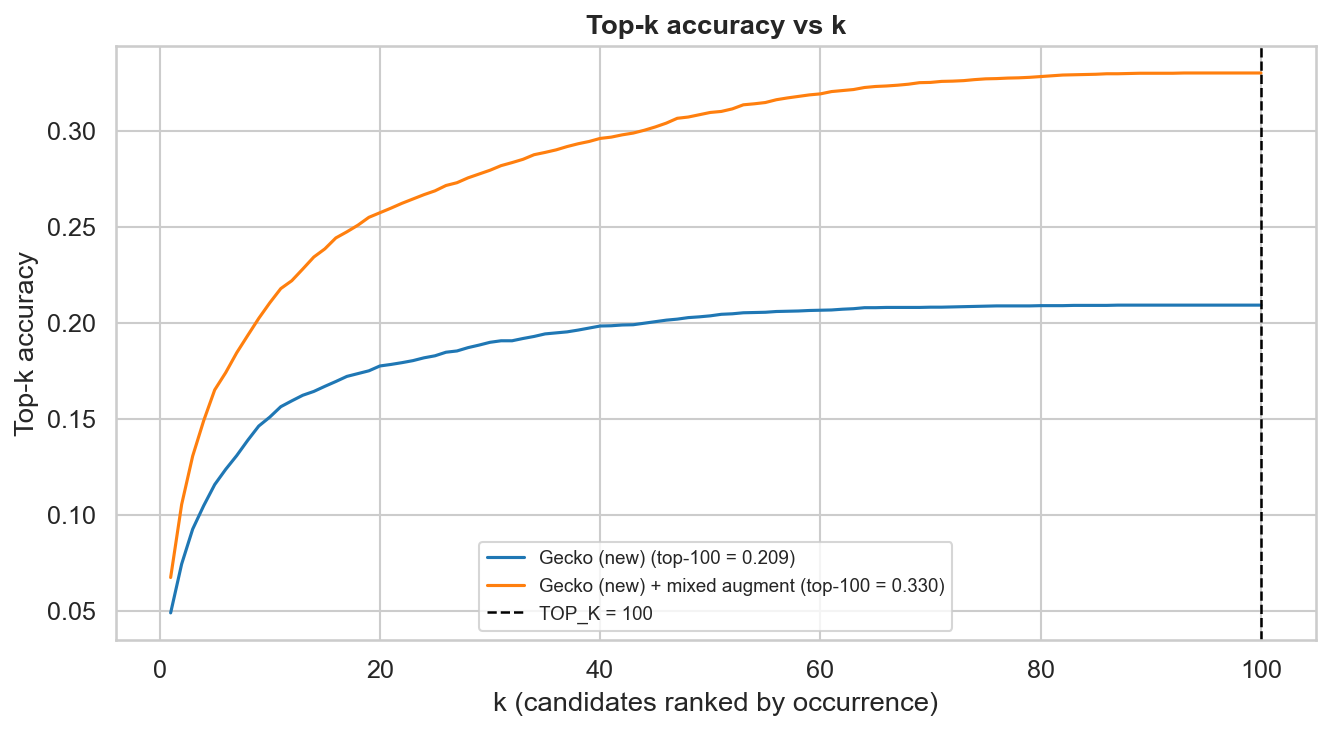

In [7]:
# Accuracy as a function of k, over the full candidate ranking.
max_k = max(len(r['pred_mols']) for recs in experiments_records.values() for r in recs)
ks = np.arange(1, max_k + 1)

fig, ax = plt.subplots(figsize=(9, 5), dpi=PLOT_DPI)
for (exp_name, records), color in zip(experiments_records.items(), sns.color_palette('tab10')):
    # rank position of the true InChI (inf if never generated) -> accuracy curve
    pos = np.array([r['ranked_inchis'].index(r['true_inchi']) + 1
                    if r['true_inchi'] in r['ranked_inchis'] else np.inf
                    for r in records])
    curve = [(pos <= k).mean() for k in ks]
    ax.plot(ks, curve, label=f'{exp_name} (top-{TOP_K} = {(pos <= TOP_K).mean():.3f})', color=color)
ax.axvline(TOP_K, color='black', linestyle='--', linewidth=1.2, label=f'TOP_K = {TOP_K}')
ax.set_xlabel('k (candidates ranked by occurrence)')
ax.set_ylabel('Top-k accuracy')
ax.set_title('Top-k accuracy vs k', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 3. Compute molecular features

In [8]:
# Load ATMOMACCS v5 feature names
atmo_names_df = pd.read_csv('explained_atmo_patterns_v5.csv', index_col=0)
maccs_names_df = pd.read_csv('explained_patterns_v5.csv', index_col=0)

atmo_feat_names = atmo_names_df['Name'].tolist()          # 38 features
maccs_feat_names = [f'MACCS_{i}' for i in range(167)]    # 167 MACCS bits
atmomaccs_feat_names = maccs_feat_names + atmo_feat_names

print(f'ATMOMACCS v5 ATMO features : {len(atmo_feat_names)}')
print(f'ATMOMACCS v5 MACCS features: {len(maccs_feat_names)}')
print(f'ATMOMACCS v5 total         : {len(atmomaccs_feat_names)}')

ATMOMACCS v5 ATMO features : 38
ATMOMACCS v5 MACCS features: 167
ATMOMACCS v5 total         : 205


In [9]:
DESC_KEYS = [
    'MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds',
    'ArRings', 'NonArRings', 'AllRings', 'Fsp3',
    'nC', 'nO', 'nN', 'nHalogen', 'nS',
    'FormalCharge', 'HeavyAtoms',
    'O_C_ratio', 'N_C_ratio',
]

def compute_rdkit_descriptors(mol):
    """Compute a panel of interpretable RDKit molecular descriptors. Raises on failure."""
    n_ar = rdMolDescriptors.CalcNumAromaticRings(mol)
    n_r  = rdMolDescriptors.CalcNumRings(mol)
    n_c  = sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 6)
    n_o  = sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 8)
    return {
        'MW':          Descriptors.ExactMolWt(mol),
        'LogP':        Descriptors.MolLogP(mol),
        'TPSA':        rdMolDescriptors.CalcTPSA(mol),
        'HBD':         rdMolDescriptors.CalcNumHBD(mol),
        'HBA':         rdMolDescriptors.CalcNumHBA(mol),
        'RotBonds':    rdMolDescriptors.CalcNumRotatableBonds(mol),
        'ArRings':     n_ar,
        'NonArRings':  max(0, n_r - n_ar),
        'AllRings':    n_r,
        'Fsp3':        rdMolDescriptors.CalcFractionCSP3(mol),
        'nC':          n_c,
        'nO':          n_o,
        'nN':          sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 7),
        'nHalogen':    sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() in (9, 17, 35, 53)),
        'nS':          sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 16),
        'FormalCharge':Chem.rdmolops.GetFormalCharge(mol),
        'HeavyAtoms':  mol.GetNumHeavyAtoms(),
        'O_C_ratio':   n_o / max(n_c, 1),
        'N_C_ratio':   sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 7) / max(n_c, 1),
    }

# Compute fingerprints and descriptors per experiment
exp_fps  = {}  # {exp_name: {'atmomaccs': arr, 'atmo': arr, 'maccs': arr}}
exp_desc = {}  # {exp_name: DataFrame}

for exp_name, records in experiments_records.items():
    atmo_fps_l, maccs_fps_l, atmomaccs_fps_l, desc_rows = [], [], [], []
    failed_fp, failed_desc = [], []

    for i, r in enumerate(records):
        mol = r['true_mol']

        try:
            atmo_fp  = pyGenATMOKeys(mol)
            maccs_fp = np.array(list(pyGenMACCSKeys(mol)), dtype=np.uint8)
            combined = np.concatenate([maccs_fp, atmo_fp])
        except Exception as e:
            failed_fp.append(i)
            print(f'[{exp_name}][fp   ] record {i}: {type(e).__name__}: {e}')
            atmo_fp  = np.zeros(38,  dtype=np.uint8)
            maccs_fp = np.zeros(167, dtype=np.uint8)
            combined = np.zeros(205, dtype=np.uint8)

        atmo_fps_l.append(atmo_fp)
        maccs_fps_l.append(maccs_fp)
        atmomaccs_fps_l.append(combined)

        try:
            desc_rows.append(compute_rdkit_descriptors(mol))
        except Exception as e:
            failed_desc.append(i)
            print(f'[{exp_name}][desc ] record {i}: {type(e).__name__}: {e}')
            desc_rows.append({k: np.nan for k in DESC_KEYS})

    exp_fps[exp_name]  = {
        'atmomaccs': np.array(atmomaccs_fps_l, dtype=np.float32),
        'atmo':      np.array(atmo_fps_l,      dtype=np.float32),
        'maccs':     np.array(maccs_fps_l,     dtype=np.float32),
    }
    exp_desc[exp_name] = pd.DataFrame(desc_rows)
    print(f'{exp_name}: fp failures={len(failed_fp)}, desc failures={len(failed_desc)}')

Gecko (new): fp failures=0, desc failures=0
Gecko (new) + mixed augment: fp failures=0, desc failures=0


In [10]:
# Build one analysis DataFrame per experiment
HIT_COLS = [f'hit_top{k}' for k in K_REPORT]
exp_dfs = {}

for exp_name, records in experiments_records.items():
    base_df = pd.DataFrame([{c: r[c] for c in HIT_COLS} for r in records])
    atmo_df = pd.DataFrame(exp_fps[exp_name]['atmo'], columns=atmo_feat_names)
    adf = pd.concat([
        base_df.reset_index(drop=True),
        exp_desc[exp_name].reset_index(drop=True),
        atmo_df.reset_index(drop=True),
    ], axis=1)
    exp_dfs[exp_name] = adf

    hit  = adf[adf[HIT]]
    miss = adf[~adf[HIT]]
    print(f'{exp_name}: n={len(adf):,}  hit={len(hit):,} ({len(hit)/len(adf):.3f})  miss={len(miss):,}')

Gecko (new): n=7,548  hit=1,579 (0.209)  miss=5,969
Gecko (new) + mixed augment: n=7,548  hit=2,491 (0.330)  miss=5,057


## 4. Molecular descriptor distributions: hit vs miss

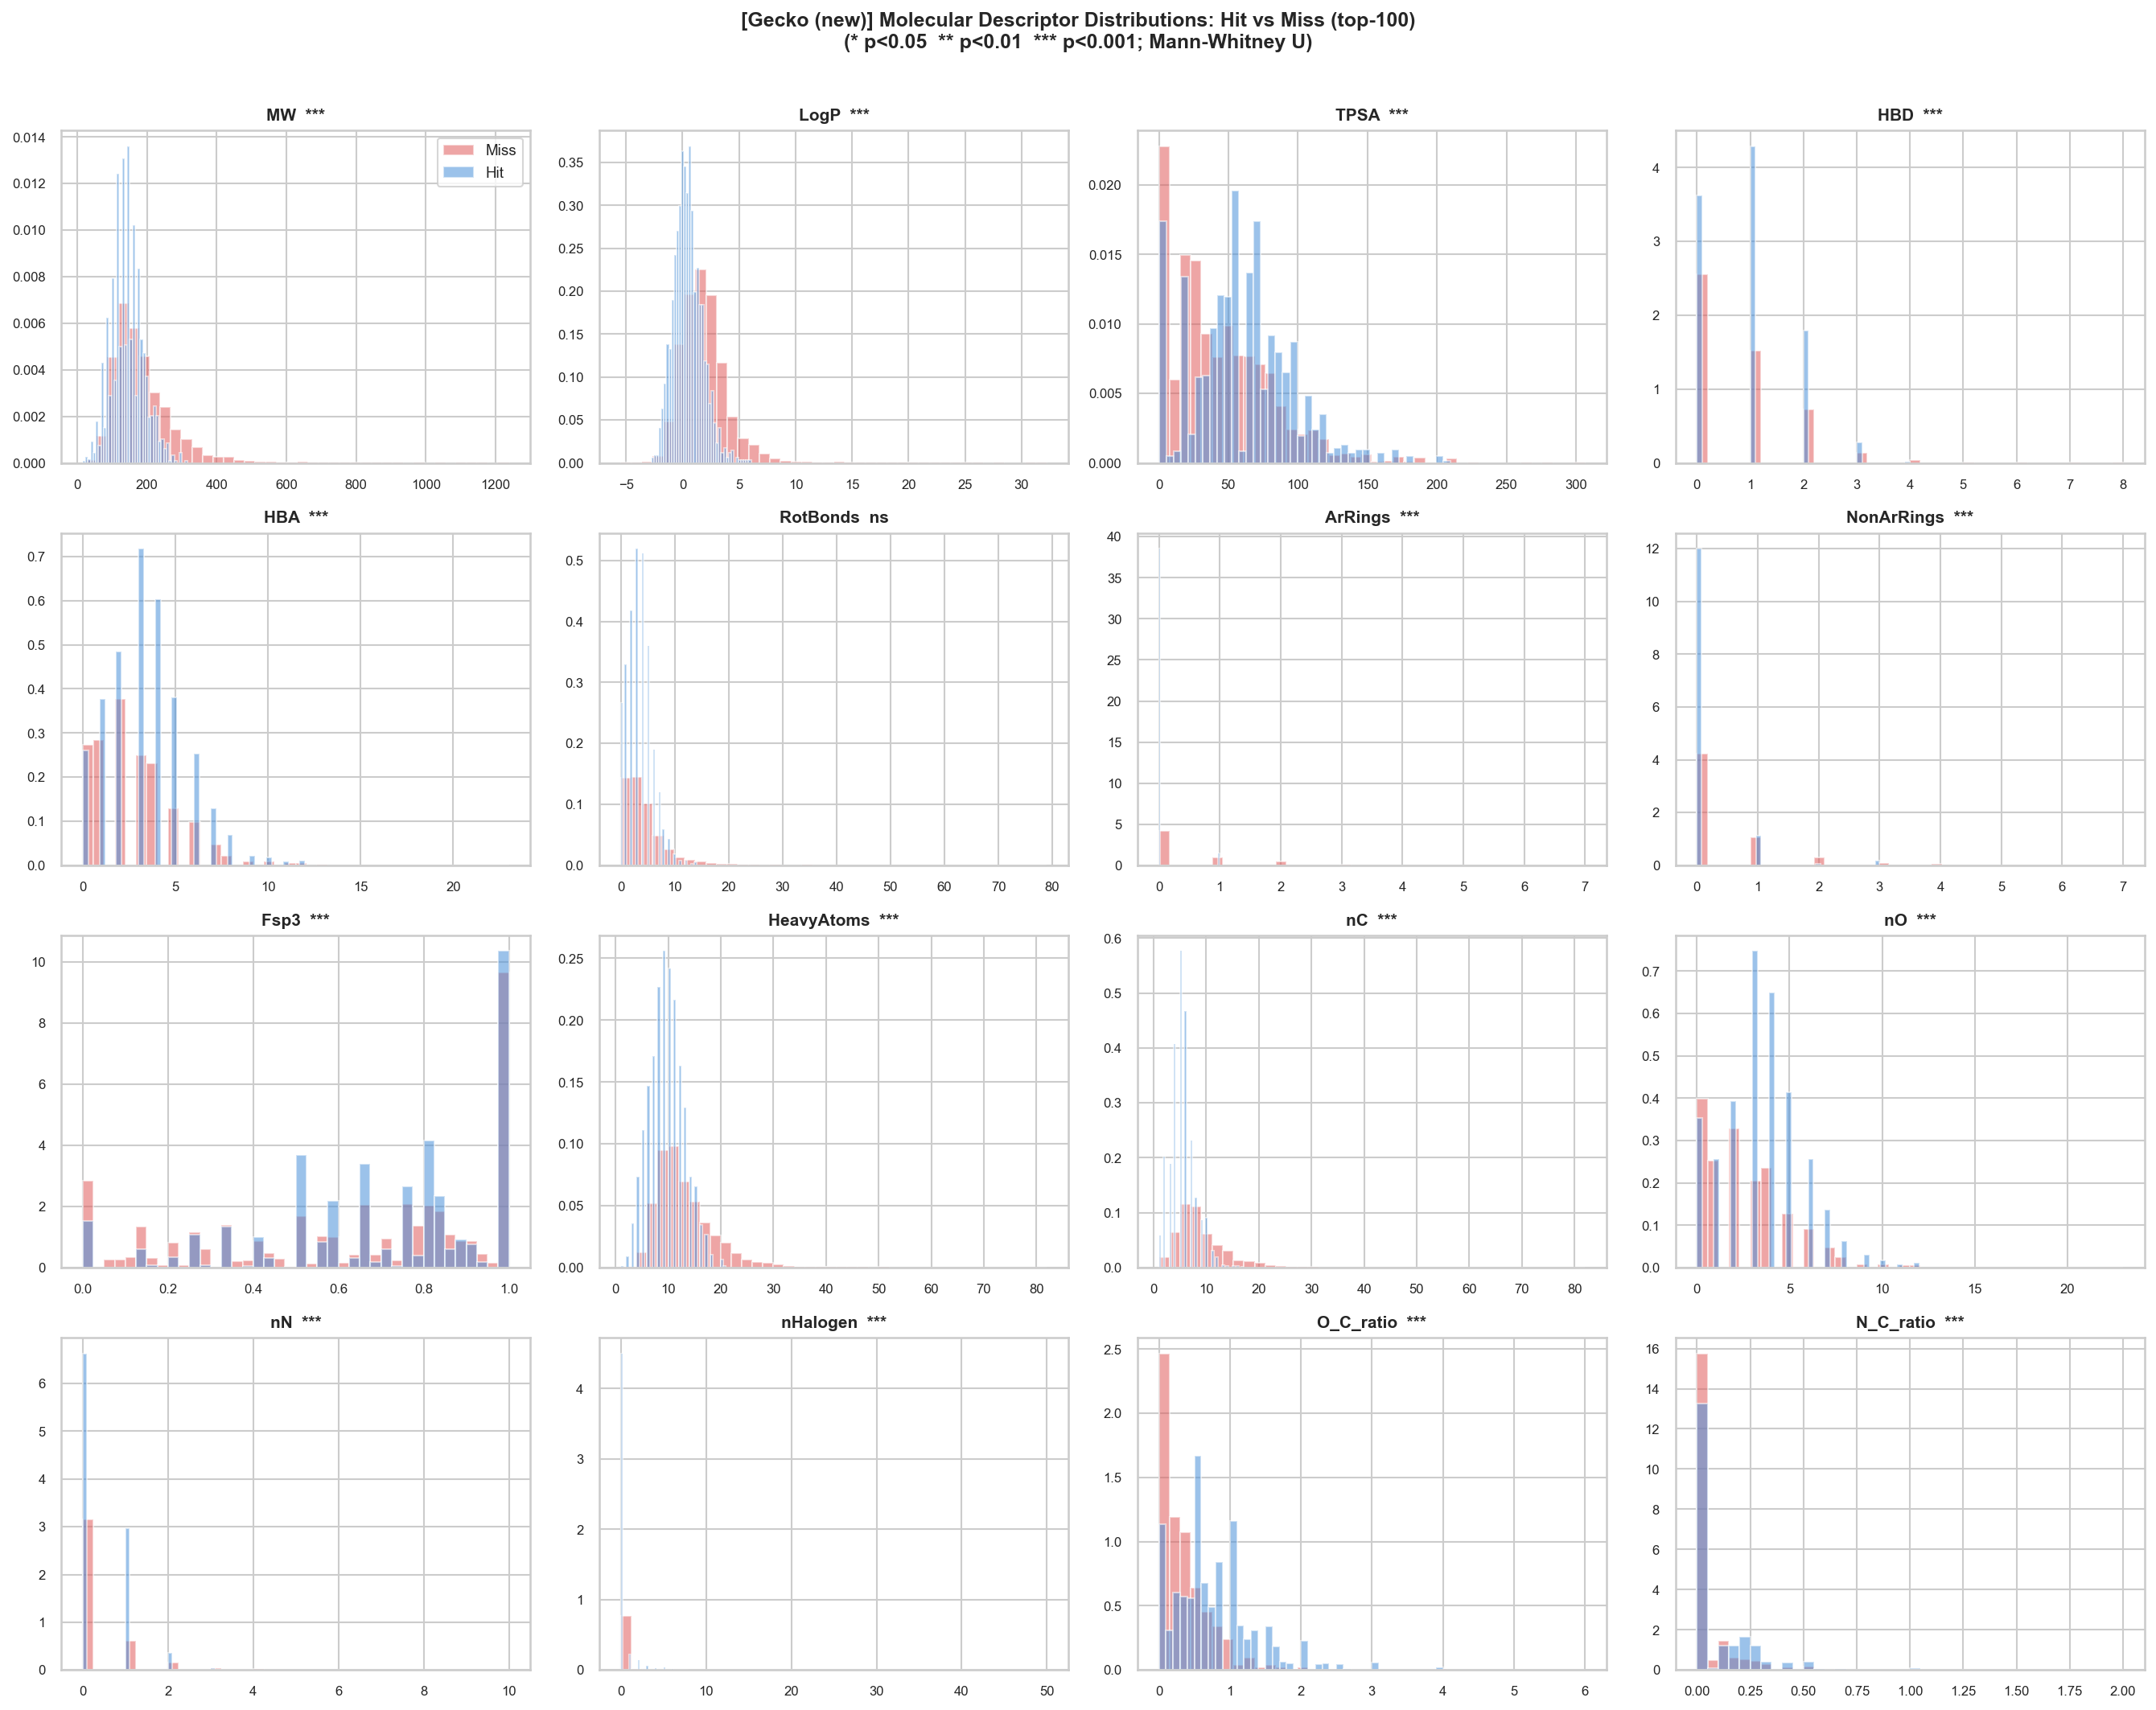

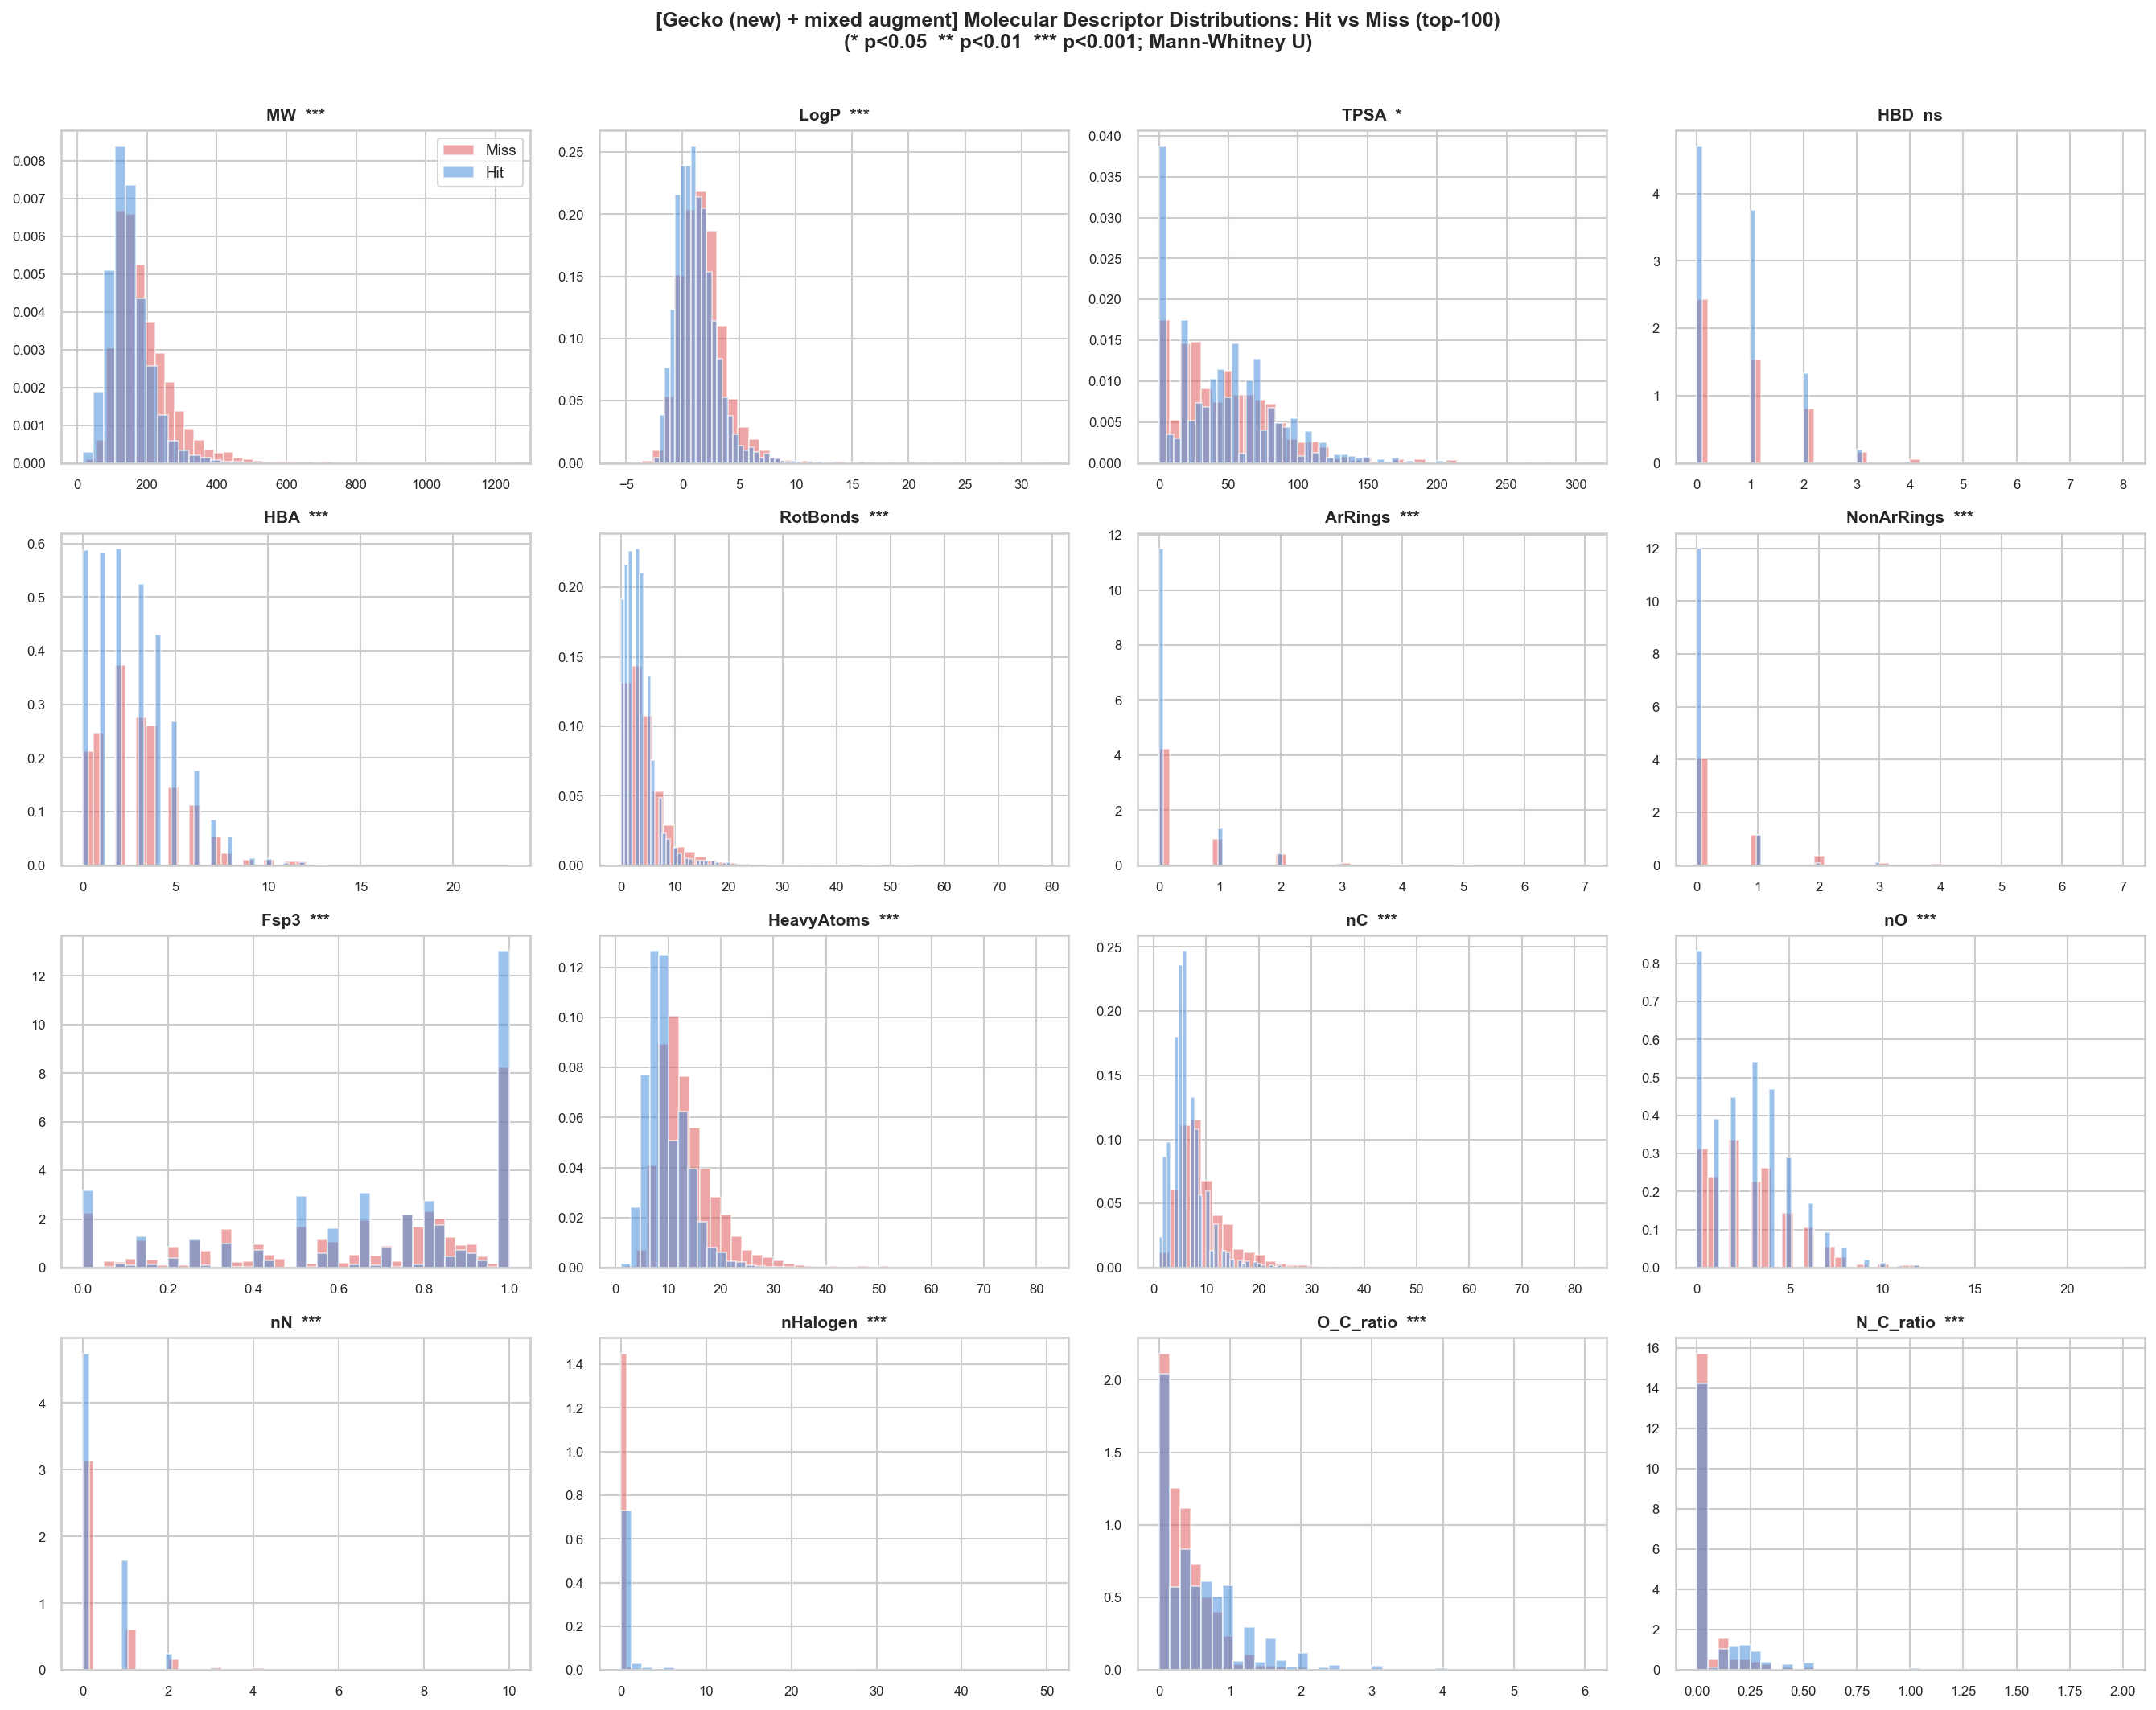

In [11]:
desc_cols = ['MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds',
             'ArRings', 'NonArRings', 'Fsp3', 'HeavyAtoms',
             'nC', 'nO', 'nN', 'nHalogen', 'O_C_ratio', 'N_C_ratio']

for exp_name, adf in exp_dfs.items():
    hit  = adf[adf[HIT]]
    miss = adf[~adf[HIT]]

    fig, axes = plt.subplots(4, 4, figsize=(18, 14), dpi=PLOT_DPI)
    axes = axes.flatten()
    for ax, col in zip(axes, desc_cols):
        h_vals = hit[col].dropna()
        m_vals = miss[col].dropna()
        ax.hist(m_vals, bins=40, alpha=0.55, color='#e05c5c', label='Miss', density=True)
        ax.hist(h_vals, bins=40, alpha=0.55, color='#4a90d9', label='Hit',  density=True)
        stat, pval = stats.mannwhitneyu(h_vals, m_vals, alternative='two-sided')
        sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'ns'))
        ax.set_title(f'{col}  {sig}', fontsize=10, fontweight='bold')
        ax.tick_params(labelsize=8)
    axes[0].legend(fontsize=9)
    fig.suptitle(f'[{exp_name}] Molecular Descriptor Distributions: Hit vs Miss (top-{TOP_K})\n'
                 f'(* p<0.05  ** p<0.01  *** p<0.001; Mann-Whitney U)',
                 y=1.01, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [12]:
for exp_name, adf in exp_dfs.items():
    hit  = adf[adf[HIT]]
    miss = adf[~adf[HIT]]
    rows = []
    for col in desc_cols:
        h_vals = hit[col].dropna()
        m_vals = miss[col].dropna()
        stat, pval = stats.mannwhitneyu(h_vals, m_vals, alternative='two-sided')
        rows.append({
            'Feature': col,
            'Mean (Hit)': h_vals.mean(),
            'Mean (Miss)': m_vals.mean(),
            'Diff (Hit-Miss)': h_vals.mean() - m_vals.mean(),
            'p-value': f'{pval:.2e}',
        })
    print(f'\n=== {exp_name} (top-{TOP_K}) ===')
    display(pd.DataFrame(rows).sort_values('p-value').round(3))


=== Gecko (new) (top-100) ===


,Feature,Mean (Hit),Mean (Miss),Diff (Hit-Miss),p-value
15,N_C_ratio,0.084,0.046,0.038,1.12e-31
14,O_C_ratio,0.739,0.348,0.391,1.38e-186
1,LogP,0.486,1.976,-1.490,1.70e-175
7,NonArRings,0.127,0.380,-0.253,2.00e-43
8,Fsp3,0.706,0.644,0.063,2.04e-07
3,HBD,0.878,0.728,0.150,2.64e-18
2,TPSA,59.813,43.978,15.835,2.66e-62
13,nHalogen,0.217,0.235,-0.019,3.48e-09
10,nC,5.379,9.487,-4.107,3.64e-282
12,nN,0.381,0.305,0.076,3.73e-20



=== Gecko (new) + mixed augment (top-100) ===


,Feature,Mean (Hit),Mean (Miss),Diff (Hit-Miss),p-value
4,HBA,2.649,2.993,-0.344,1.20e-10
1,LogP,1.215,1.886,-0.672,1.21e-42
8,Fsp3,0.684,0.643,0.041,1.33e-11
0,MW,151.631,192.327,-40.695,1.63e-106
13,nHalogen,0.544,0.077,0.467,1.64e-109
3,HBD,0.707,0.785,-0.079,1.86e-01
9,HeavyAtoms,9.836,13.267,-3.431,1.86e-164
6,ArRings,0.177,0.387,-0.210,1.87e-35
2,TPSA,46.169,47.843,-1.674,3.17e-02
10,nC,6.211,9.818,-3.607,4.21e-274


## 5. ATMOMACCS v5 ATMO feature analysis


=== Gecko (new) — ATMO features that HURT top-100 accuracy ===


,Feature,n (has),Hit rate (has),Hit rate (lacks),Delta (has-lacks),p-value
29,aromatic ring,1657,0.035,0.258,-0.223,0.000
5,aromatic CH,1624,0.036,0.257,-0.221,0.000
10,ether,397,0.005,0.221,-0.215,0.000
23,"ether, aromatic",197,0.000,0.215,-0.215,0.000
25,"amine, aromatic",174,0.000,0.214,-0.214,0.000
2,"amine, tertiary",72,0.000,0.211,-0.211,0.000
28,nC-OHside-a,39,0.000,0.210,-0.210,0.001
15,amide,37,0.000,0.210,-0.210,0.002
21,"amide, tertiary",32,0.000,0.210,-0.210,0.004
11,peroxide,197,0.005,0.215,-0.210,0.000



=== Gecko (new) — ATMO features that HELP top-100 accuracy ===


,Feature,n (has),Hit rate (has),Hit rate (lacks),Delta (has-lacks),p-value
14,hydroperoxide,927,0.370,0.187,0.183,0.0
20,aldehyde,991,0.383,0.183,0.201,0.0
6,carbonyl,2199,0.371,0.143,0.228,0.0
18,carbonylperoxynitrate,278,0.493,0.198,0.294,0.0
16,nitrate,684,0.534,0.177,0.357,0.0


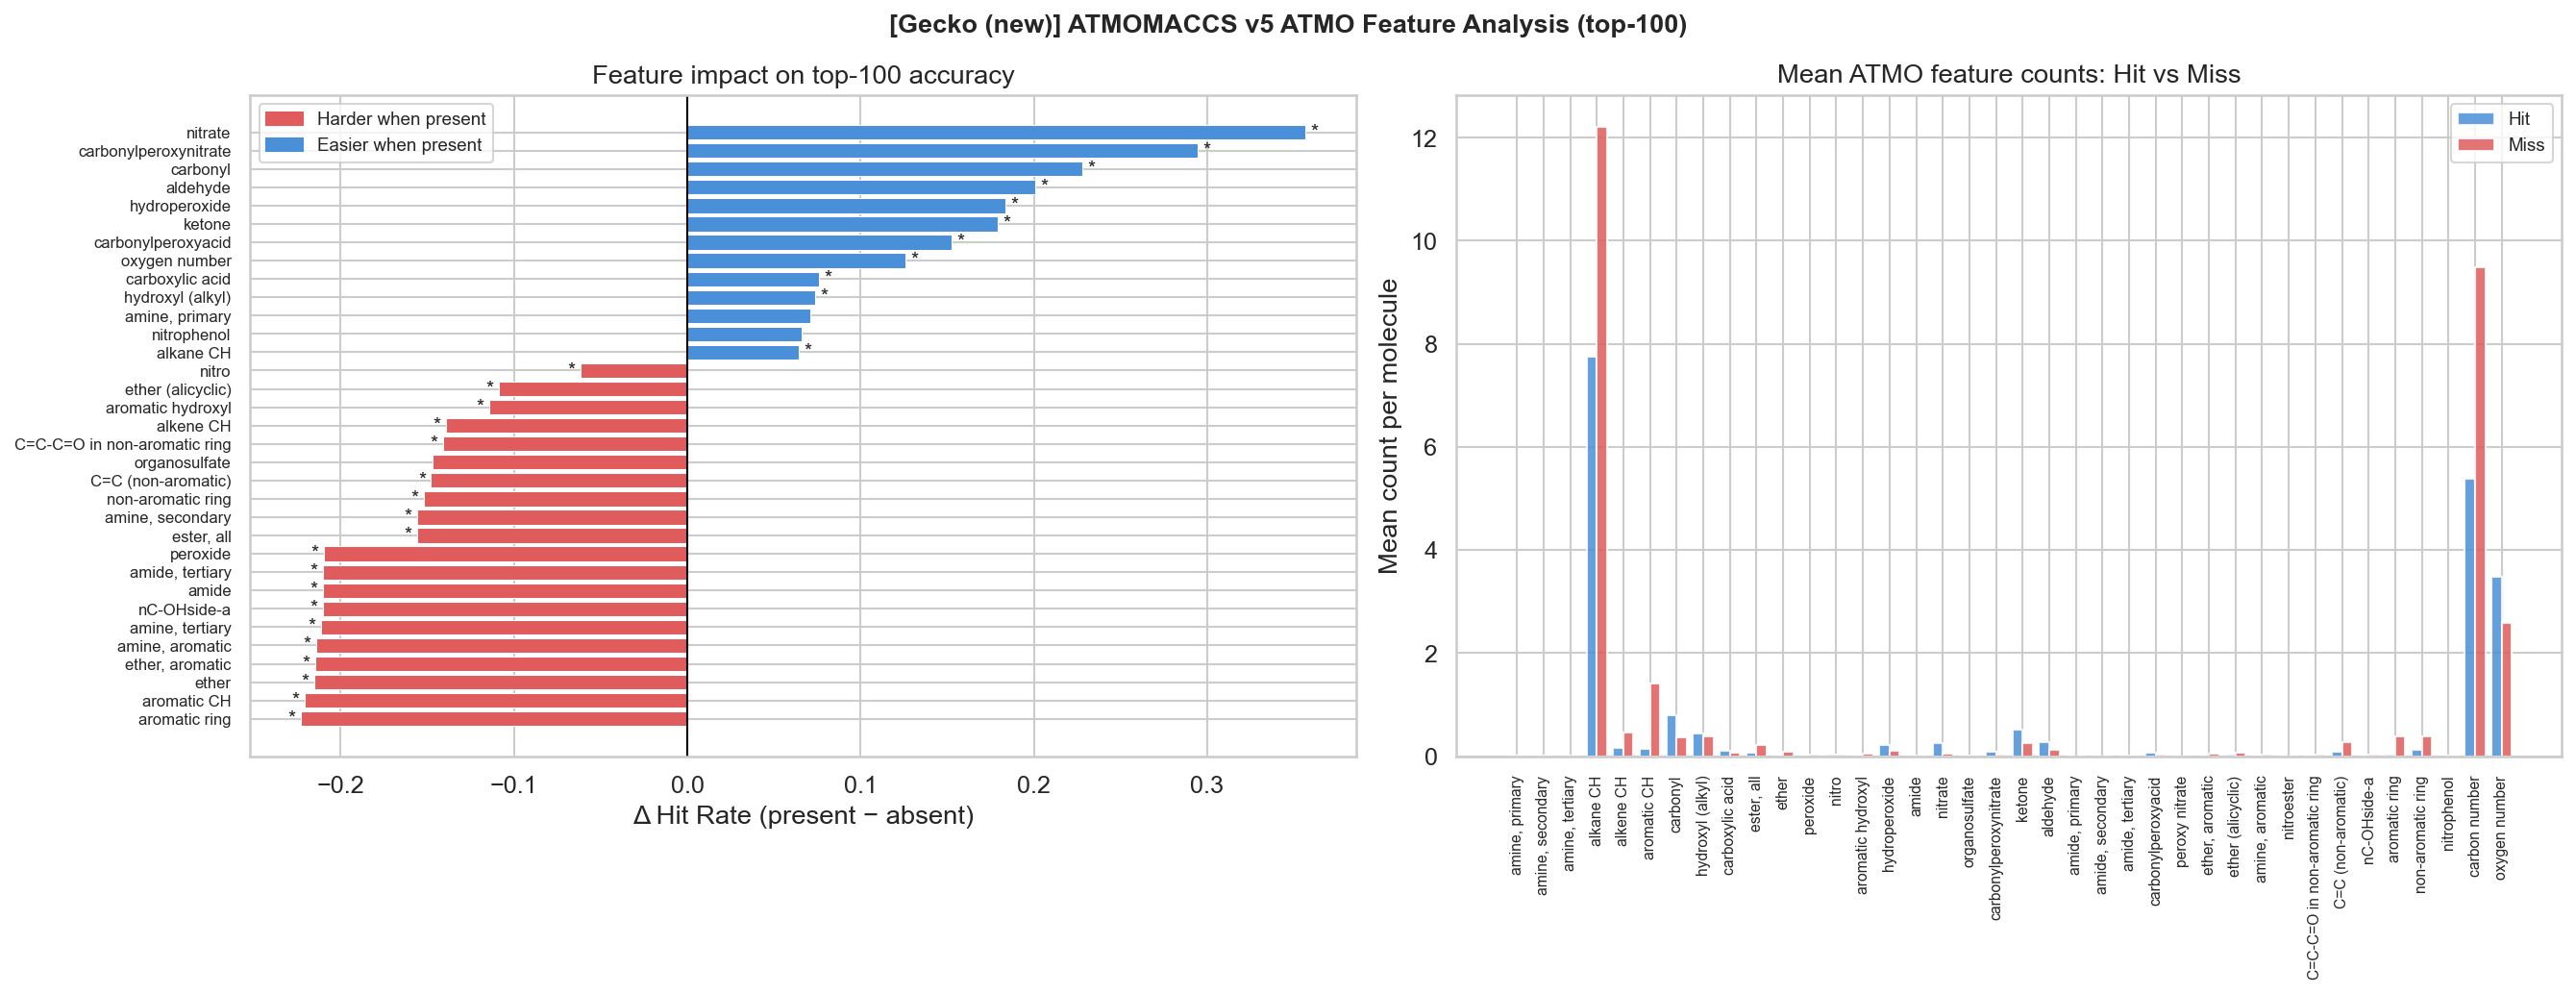


=== Gecko (new) + mixed augment — ATMO features that HURT top-100 accuracy ===


,Feature,n (has),Hit rate (has),Hit rate (lacks),Delta (has-lacks),p-value
11,peroxide,197,0.030,0.338,-0.308,0.0
28,nC-OHside-a,39,0.026,0.332,-0.306,0.0
15,amide,37,0.027,0.332,-0.304,0.0
21,"amide, tertiary",32,0.031,0.331,-0.300,0.0
9,"ester, all",1003,0.102,0.365,-0.263,0.0
10,ether,397,0.088,0.343,-0.255,0.0
26,C=C-C=O in non-aromatic ring,141,0.092,0.335,-0.242,0.0
30,non-aromatic ring,1721,0.147,0.384,-0.237,0.0
23,"ether, aromatic",197,0.107,0.336,-0.229,0.0
24,ether (alicyclic),333,0.126,0.339,-0.213,0.0



=== Gecko (new) + mixed augment — ATMO features that HELP top-100 accuracy ===


,Feature,n (has),Hit rate (has),Hit rate (lacks),Delta (has-lacks),p-value
6,carbonyl,2199,0.406,0.299,0.107,0.000
0,"amine, primary",68,0.441,0.329,0.112,0.050
18,carbonylperoxynitrate,278,0.522,0.323,0.199,0.000
16,nitrate,684,0.538,0.309,0.229,0.000
17,organosulfate,16,0.562,0.330,0.233,0.048


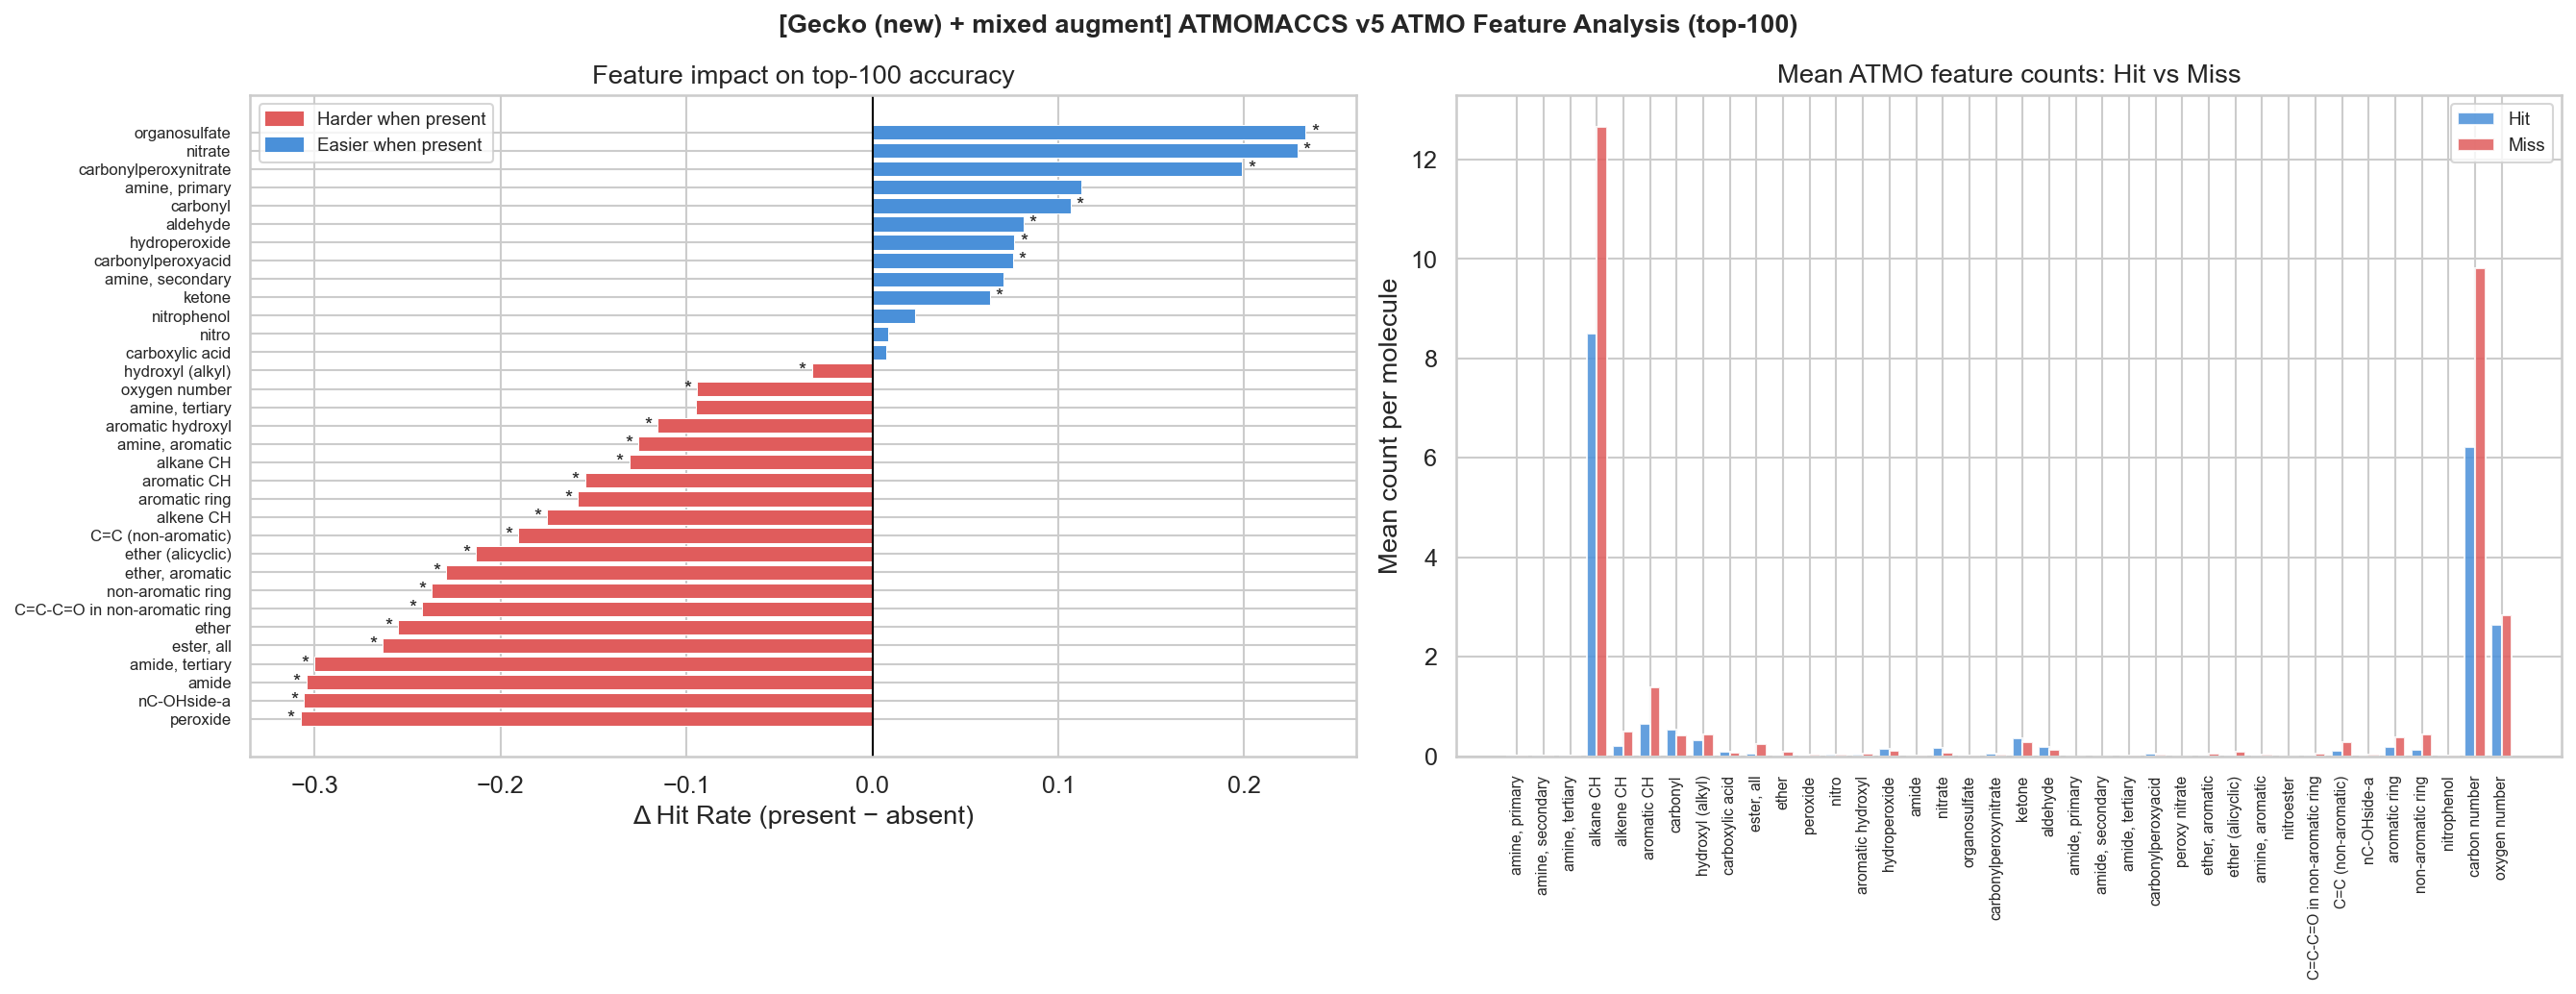

In [13]:
for exp_name, adf in exp_dfs.items():
    hit  = adf[adf[HIT]]
    miss = adf[~adf[HIT]]

    atmo_rows = []
    for feat in atmo_feat_names:
        has_feat   = adf[adf[feat] > 0]
        lacks_feat = adf[adf[feat] == 0]
        if len(has_feat) < 10:
            continue
        hr_has   = has_feat[HIT].mean()
        hr_lacks = lacks_feat[HIT].mean() if len(lacks_feat) > 0 else np.nan
        if len(lacks_feat) >= 5:
            _, pval = stats.mannwhitneyu(
                has_feat[HIT].astype(float),
                lacks_feat[HIT].astype(float),
                alternative='two-sided'
            )
        else:
            pval = np.nan
        atmo_rows.append({
            'Feature': feat,
            'n (has)': len(has_feat),
            'Hit rate (has)': hr_has,
            'Hit rate (lacks)': hr_lacks,
            'Delta (has-lacks)': hr_has - hr_lacks if not np.isnan(hr_lacks) else np.nan,
            'p-value': pval,
        })
    atmo_stats = pd.DataFrame(atmo_rows).sort_values('Delta (has-lacks)')

    print(f'\n=== {exp_name} — ATMO features that HURT top-{TOP_K} accuracy ===')
    display(atmo_stats[atmo_stats['Delta (has-lacks)'] < 0].head(10).round(3))
    print(f'\n=== {exp_name} — ATMO features that HELP top-{TOP_K} accuracy ===')
    display(atmo_stats[atmo_stats['Delta (has-lacks)'] > 0].tail(5).round(3))

    # Bar plot: hit-rate delta per feature
    plot_df = atmo_stats.dropna(subset=['Delta (has-lacks)'])
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=PLOT_DPI)

    colors = ['#e05c5c' if d < 0 else '#4a90d9' for d in plot_df['Delta (has-lacks)']]
    axes[0].barh(plot_df['Feature'], plot_df['Delta (has-lacks)'], color=colors, edgecolor='white', linewidth=0.5)
    axes[0].axvline(0, color='black', linewidth=1)
    for i, (_, row) in enumerate(plot_df.iterrows()):
        if pd.notna(row['p-value']) and row['p-value'] < 0.05:
            x = row['Delta (has-lacks)']
            axes[0].text(x + (0.003 if x >= 0 else -0.003), i, '*',
                         va='center', ha='left' if x >= 0 else 'right', fontsize=10)
    axes[0].set_xlabel('Δ Hit Rate (present − absent)')
    axes[0].set_title(f'Feature impact on top-{TOP_K} accuracy')
    axes[0].tick_params(axis='y', labelsize=8)
    red_p  = mpatches.Patch(color='#e05c5c', label='Harder when present')
    blue_p = mpatches.Patch(color='#4a90d9', label='Easier when present')
    axes[0].legend(handles=[red_p, blue_p], fontsize=9)

    # Mean count: hit vs miss
    x = np.arange(len(atmo_feat_names))
    w = 0.38
    axes[1].bar(x - w/2, hit[atmo_feat_names].mean(),  width=w, label='Hit',  color='#4a90d9', alpha=0.85)
    axes[1].bar(x + w/2, miss[atmo_feat_names].mean(), width=w, label='Miss', color='#e05c5c', alpha=0.85)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(atmo_feat_names, rotation=90, fontsize=7.5)
    axes[1].set_ylabel('Mean count per molecule')
    axes[1].set_title('Mean ATMO feature counts: Hit vs Miss')
    axes[1].legend(fontsize=9)

    fig.suptitle(f'[{exp_name}] ATMOMACCS v5 ATMO Feature Analysis (top-{TOP_K})',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 6. PCA of ATMOMACCS v5 fingerprint space


=== Gecko (new) — explained variance ratio (PC1-10) ===
[0.108 0.07  0.065 0.048 0.043 0.035 0.03  0.026 0.025 0.022]
Cumulative (PC1-5): 0.334


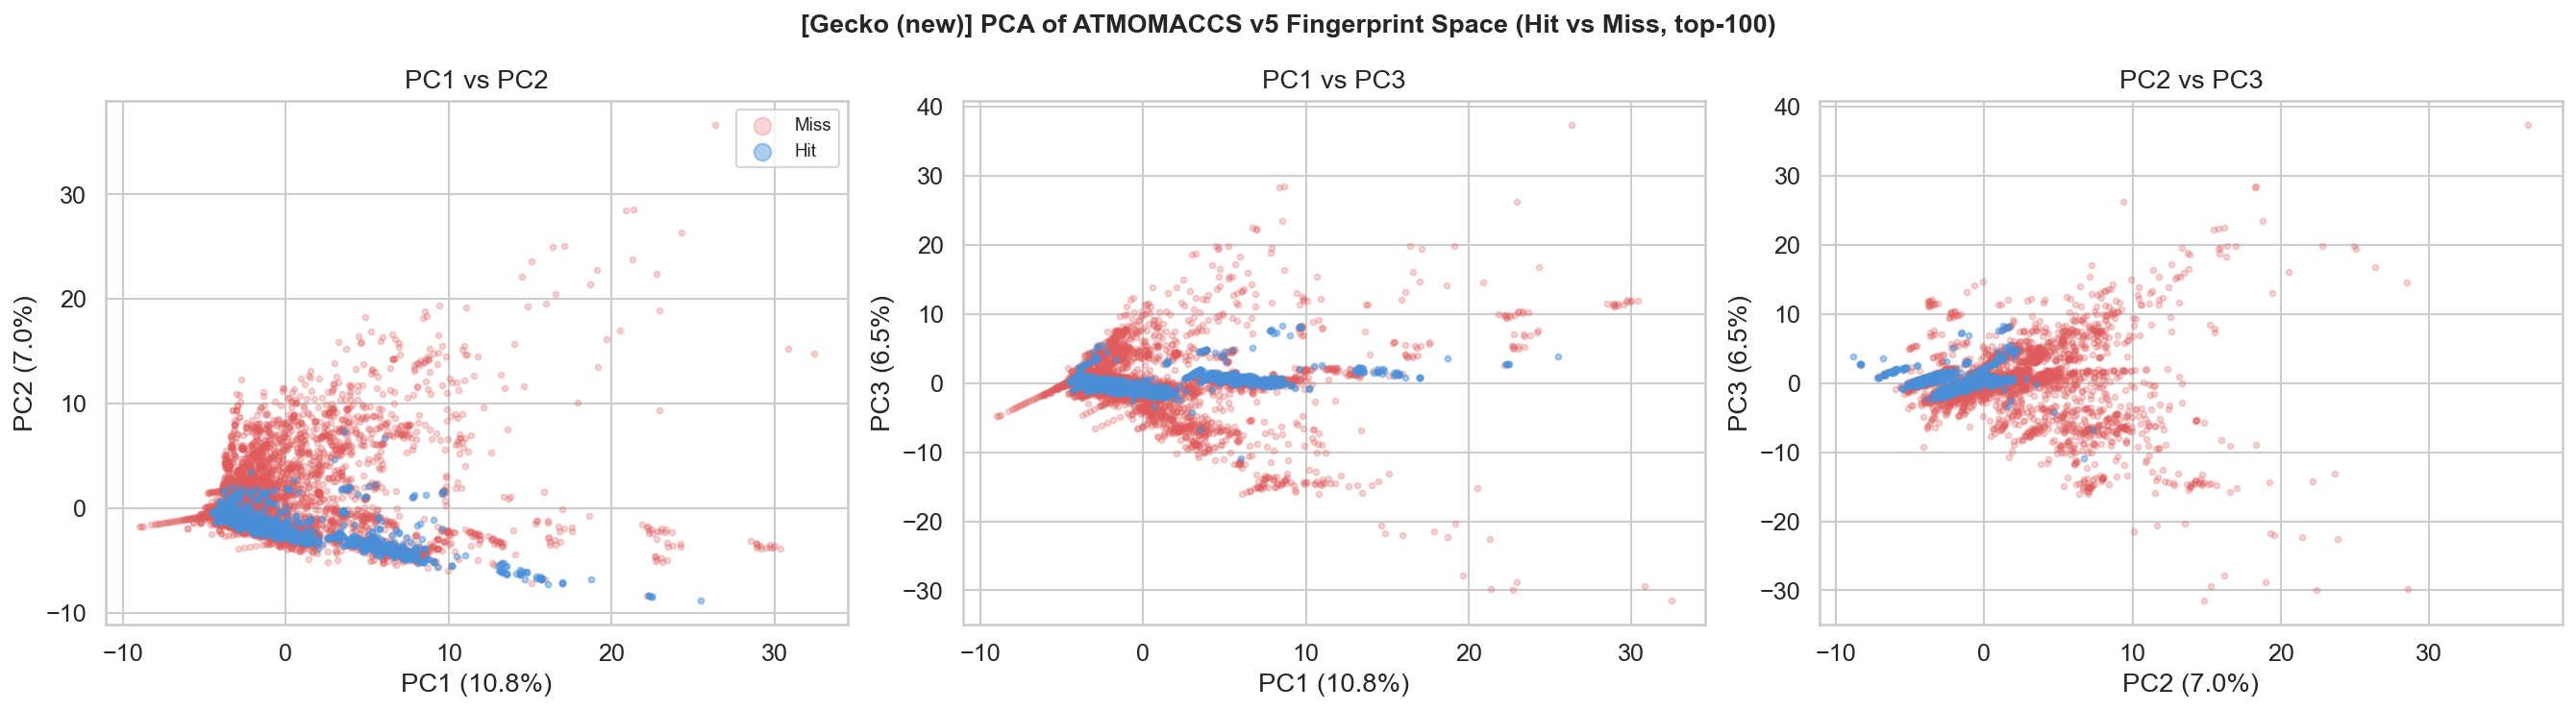

  Top 10 contributors to PC1:
   {'MACCS_63': 0.16824015974998474, 'MACCS_94': 0.16837574541568756, 'oxygen number': 0.1907176673412323, 'MACCS_140': 0.1907176822423935, 'MACCS_146': 0.1907176822423935, 'MACCS_159': 0.1907176822423935, 'MACCS_164': 0.1907176822423935, 'MACCS_102': 0.19770124554634094, 'MACCS_124': 0.1986646205186844, 'MACCS_130': 0.1986646205186844}
  Top 10 contributors to PC2:
   {'MACCS_73': 0.1557016670703888, 'MACCS_60': 0.15581193566322327, 'MACCS_67': 0.15816998481750488, 'MACCS_145': 0.17518602311611176, 'MACCS_163': 0.17518602311611176, 'MACCS_165': 0.18676573038101196, 'aromatic CH': 0.19233766198158264, 'MACCS_125': 0.20572572946548462, 'aromatic ring': 0.20572572946548462, 'MACCS_162': 0.20928509533405304}

=== Gecko (new) + mixed augment — explained variance ratio (PC1-10) ===
[0.108 0.07  0.065 0.048 0.043 0.035 0.03  0.026 0.025 0.022]
Cumulative (PC1-5): 0.334


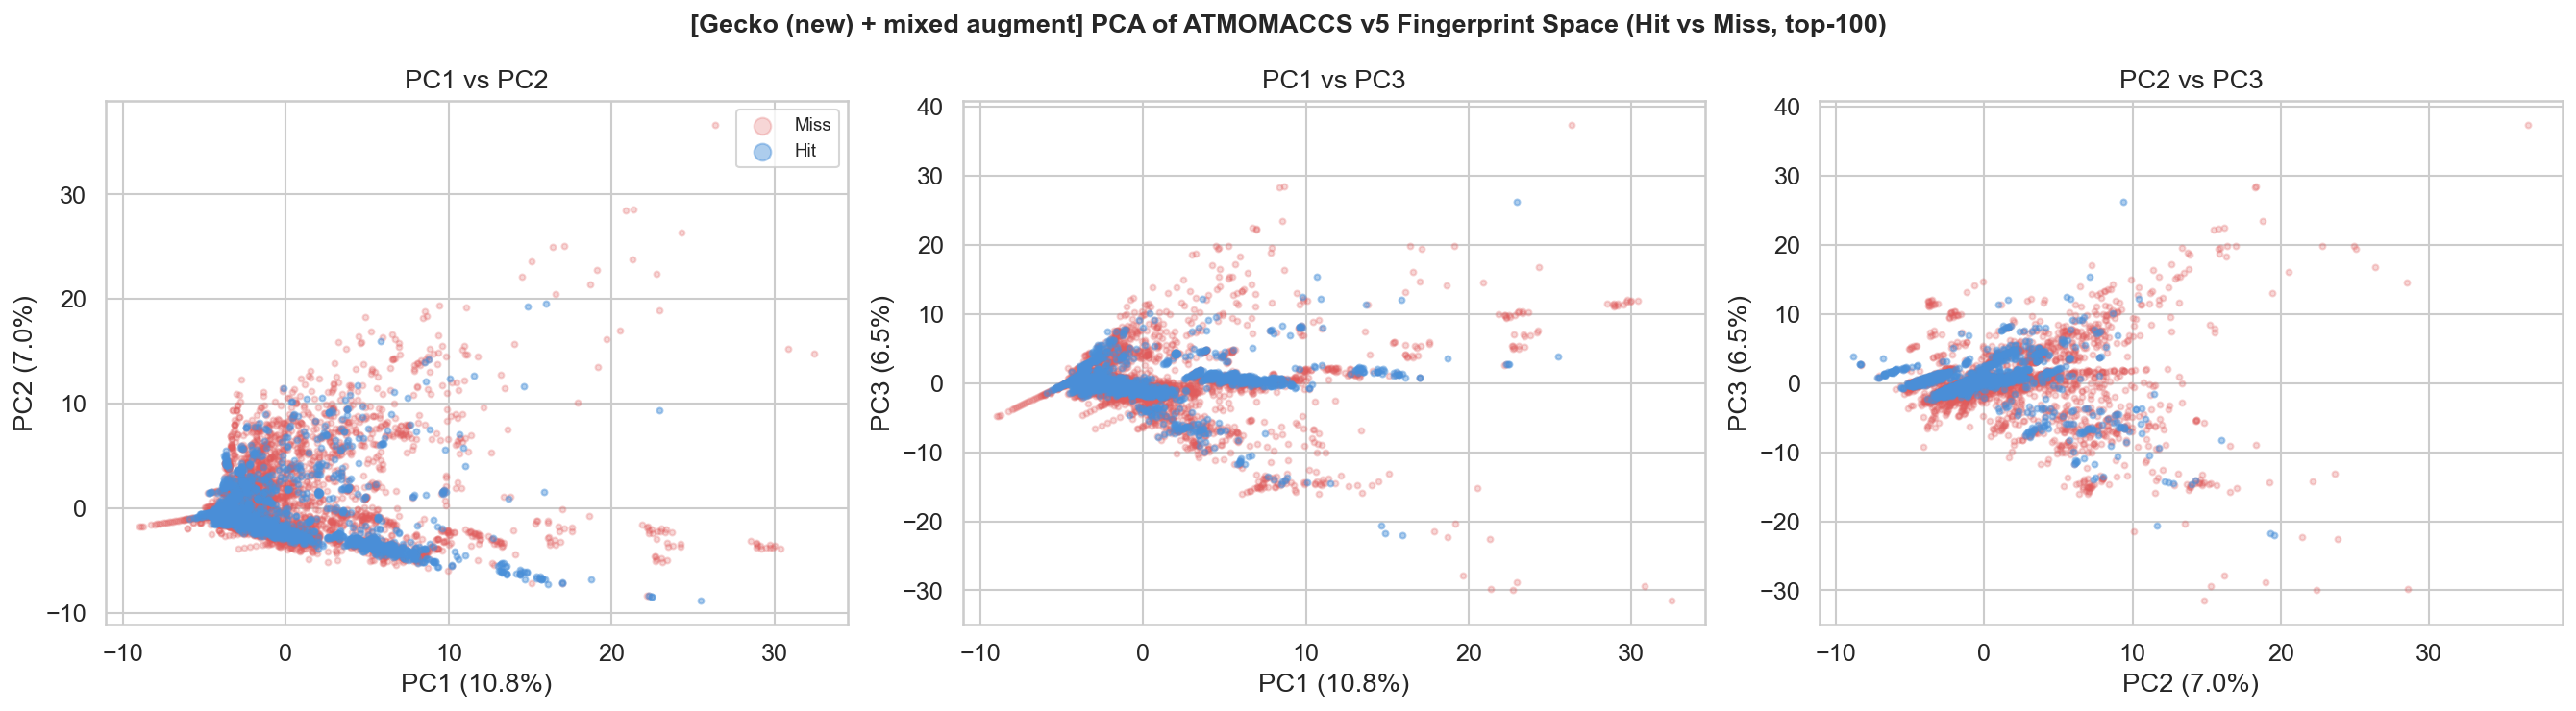

  Top 10 contributors to PC1:
   {'MACCS_63': 0.16824015974998474, 'MACCS_94': 0.16837574541568756, 'oxygen number': 0.1907176673412323, 'MACCS_140': 0.1907176822423935, 'MACCS_146': 0.1907176822423935, 'MACCS_159': 0.1907176822423935, 'MACCS_164': 0.1907176822423935, 'MACCS_102': 0.19770124554634094, 'MACCS_124': 0.1986646205186844, 'MACCS_130': 0.1986646205186844}
  Top 10 contributors to PC2:
   {'MACCS_73': 0.1557016670703888, 'MACCS_60': 0.15581193566322327, 'MACCS_67': 0.15816998481750488, 'MACCS_145': 0.17518602311611176, 'MACCS_163': 0.17518602311611176, 'MACCS_165': 0.18676573038101196, 'aromatic CH': 0.19233766198158264, 'MACCS_125': 0.20572572946548462, 'aromatic ring': 0.20572572946548462, 'MACCS_162': 0.20928509533405304}


In [14]:
exp_pca_results = {}  # {exp_name: {'pcs': arr, 'pca': PCA, 'fp_scaled': arr, 'scaler': scaler}}

for exp_name, adf in exp_dfs.items():
    hit_mask   = adf[HIT].values
    atmomaccs  = exp_fps[exp_name]['atmomaccs']

    scaler    = StandardScaler()
    fp_scaled = scaler.fit_transform(atmomaccs)
    pca       = PCA(n_components=10, random_state=42)
    pcs       = pca.fit_transform(fp_scaled)

    exp_pca_results[exp_name] = {'pcs': pcs, 'pca': pca, 'fp_scaled': fp_scaled, 'scaler': scaler}

    print(f'\n=== {exp_name} — explained variance ratio (PC1-10) ===')
    print(np.round(pca.explained_variance_ratio_, 3))
    print(f'Cumulative (PC1-5): {pca.explained_variance_ratio_[:5].sum():.3f}')

    # PCA scatter: hit vs miss
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=PLOT_DPI)
    for ax, (i, j) in zip(axes, [(0,1), (0,2), (1,2)]):
        ax.scatter(pcs[~hit_mask, i], pcs[~hit_mask, j], c='#e05c5c', alpha=0.25, s=8,
                   label='Miss', rasterized=True)
        ax.scatter(pcs[hit_mask,  i], pcs[hit_mask,  j], c='#4a90d9', alpha=0.45, s=8,
                   label='Hit',  rasterized=True)
        ax.set_xlabel(f'PC{i+1} ({pca.explained_variance_ratio_[i]*100:.1f}%)')
        ax.set_ylabel(f'PC{j+1} ({pca.explained_variance_ratio_[j]*100:.1f}%)')
        ax.set_title(f'PC{i+1} vs PC{j+1}')
    axes[0].legend(markerscale=3, fontsize=9)
    fig.suptitle(f'[{exp_name}] PCA of ATMOMACCS v5 Fingerprint Space (Hit vs Miss, top-{TOP_K})',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # PCA loadings
    loadings = pd.DataFrame(
        pca.components_[:5].T,
        index=atmomaccs_feat_names,
        columns=[f'PC{i+1}' for i in range(5)]
    )
    for pc in ['PC1', 'PC2']:
        top = loadings[pc].abs().nlargest(10).index
        print(f'  Top 10 contributors to {pc}:')
        print('  ', loadings.loc[top, pc].sort_values().to_dict())

## 7. K-means clustering

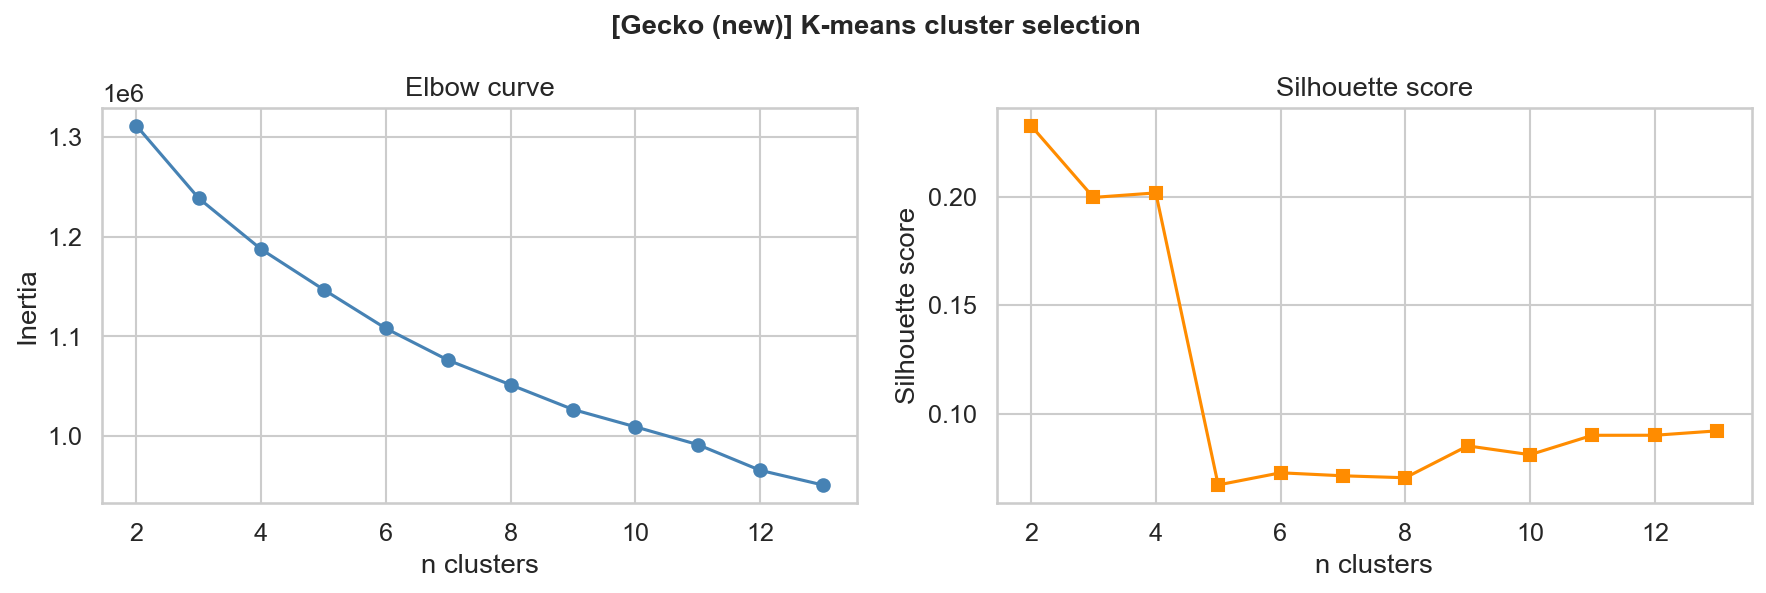

Gecko (new): best n clusters = 2


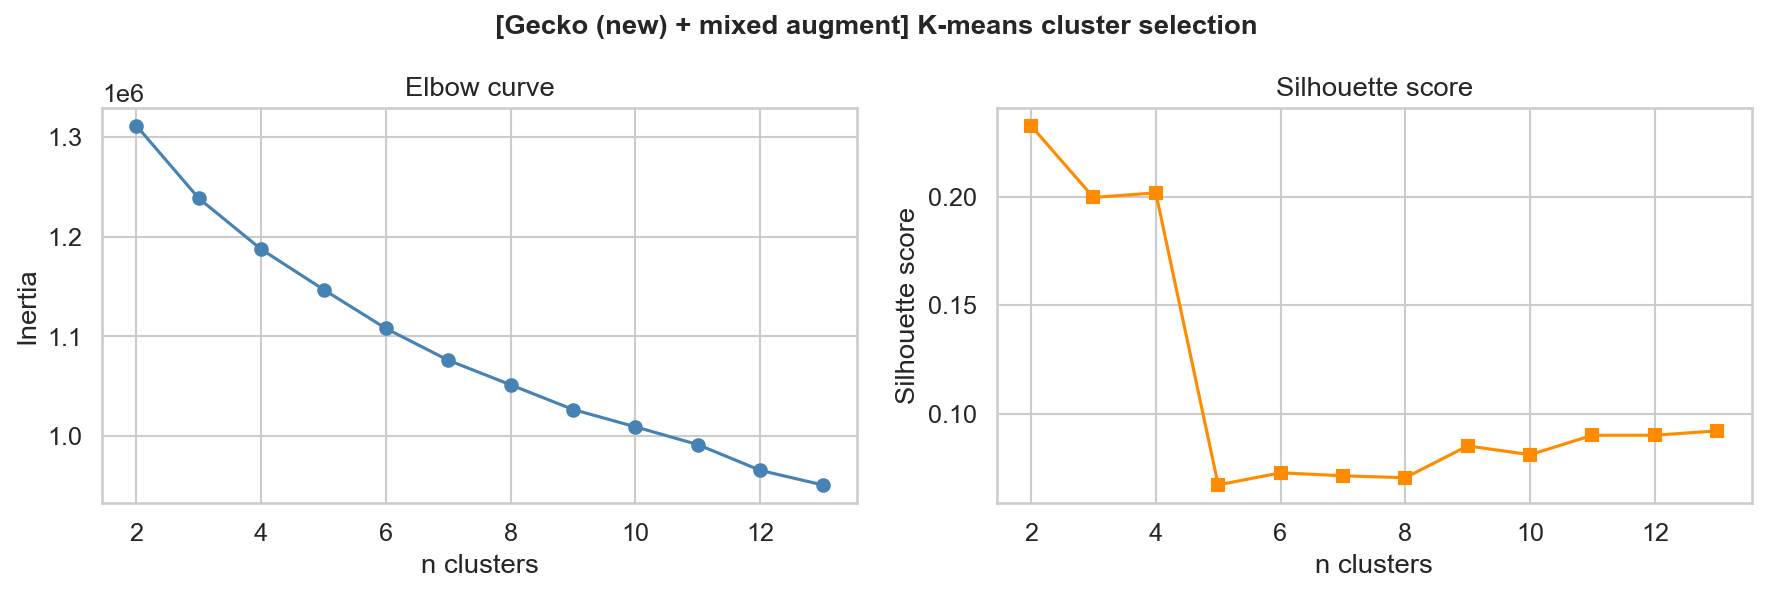

Gecko (new) + mixed augment: best n clusters = 2


In [15]:
exp_best_k = {}  # {exp_name: best number of clusters from silhouette}

for exp_name in exp_dfs:
    fp_scaled = exp_pca_results[exp_name]['fp_scaled']
    k_range   = range(2, 14)
    inertias, sil_scores = [], []

    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=42, max_iter=300)
        labels = km.fit_predict(fp_scaled)
        inertias.append(km.inertia_)
        sil_scores.append(silhouette_score(fp_scaled, labels,
                                           sample_size=min(5000, len(fp_scaled)), random_state=42))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), dpi=PLOT_DPI)
    ax1.plot(list(k_range), inertias,   'o-', color='steelblue')
    ax1.set_xlabel('n clusters'); ax1.set_ylabel('Inertia'); ax1.set_title('Elbow curve')
    ax2.plot(list(k_range), sil_scores, 's-', color='darkorange')
    ax2.set_xlabel('n clusters'); ax2.set_ylabel('Silhouette score'); ax2.set_title('Silhouette score')
    fig.suptitle(f'[{exp_name}] K-means cluster selection', fontweight='bold')
    plt.tight_layout()
    plt.show()

    best_k = list(k_range)[np.argmax(sil_scores)]
    exp_best_k[exp_name] = best_k
    print(f'{exp_name}: best n clusters = {best_k}')


=== Gecko (new) (n clusters=3) ===


,n,hit_rate_top1,hit_rate_top3,hit_rate_top5,hit_rate_top10,hit_rate_top20,hit_rate_top50,hit_rate_top100,MW_mean,nC_mean,nO_mean,ArRings_mean,Fsp3_mean
cluster,,,,,,,,,,,,,
2,417,0.000,0.000,0.002,0.005,0.007,0.007,0.007,285.446,11.971,4.918,1.110,0.486
0,5975,0.033,0.071,0.091,0.124,0.149,0.174,0.180,166.524,8.715,2.059,0.288,0.665
1,1156,0.147,0.237,0.283,0.343,0.386,0.429,0.435,204.409,6.968,5.659,0.186,0.675


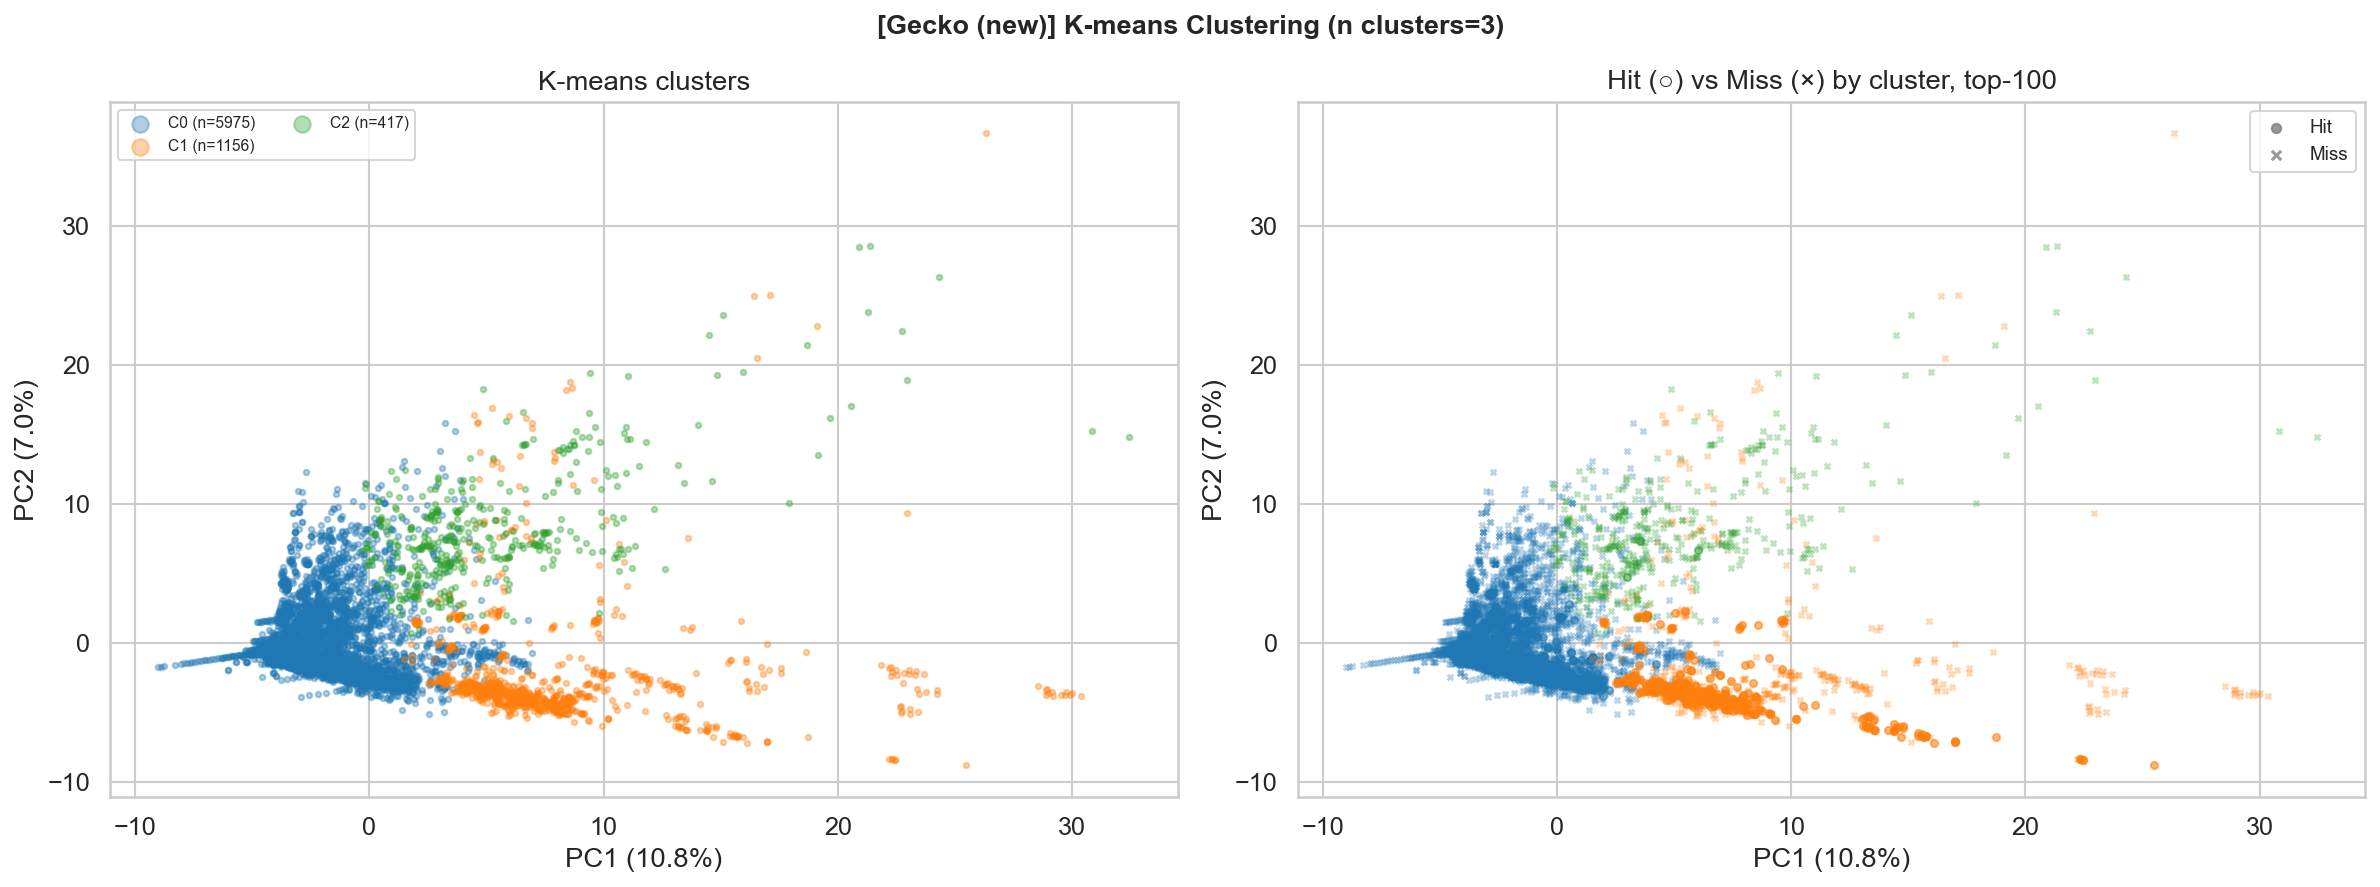

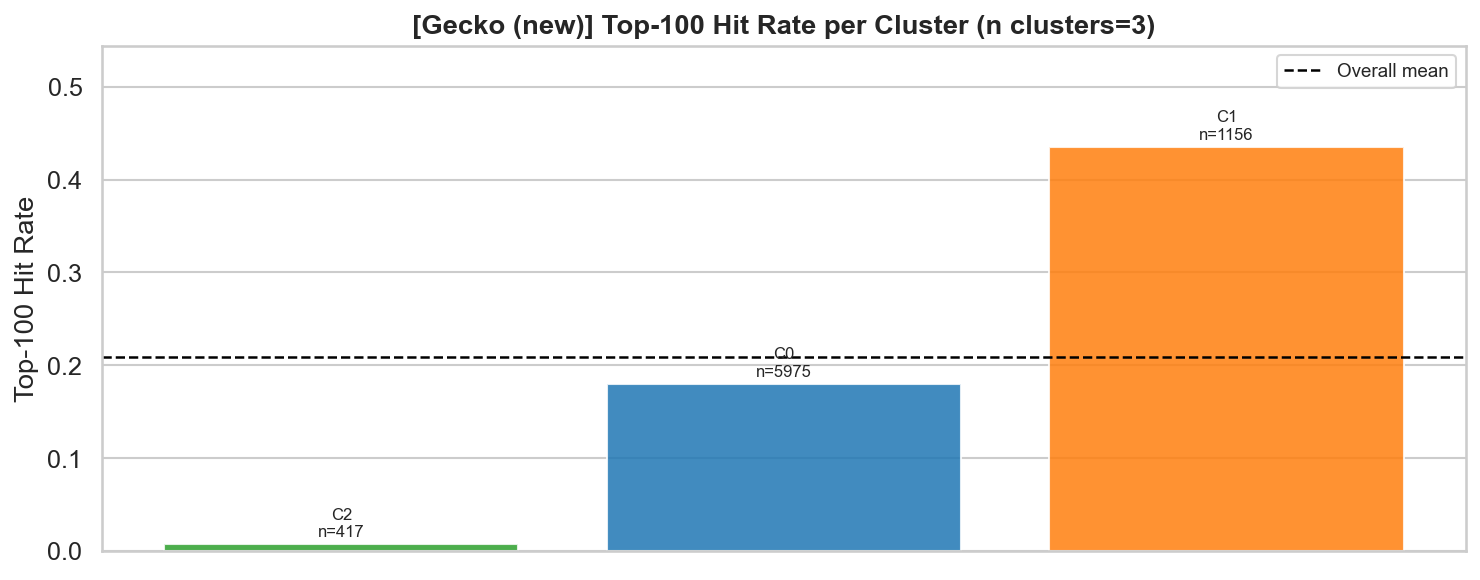

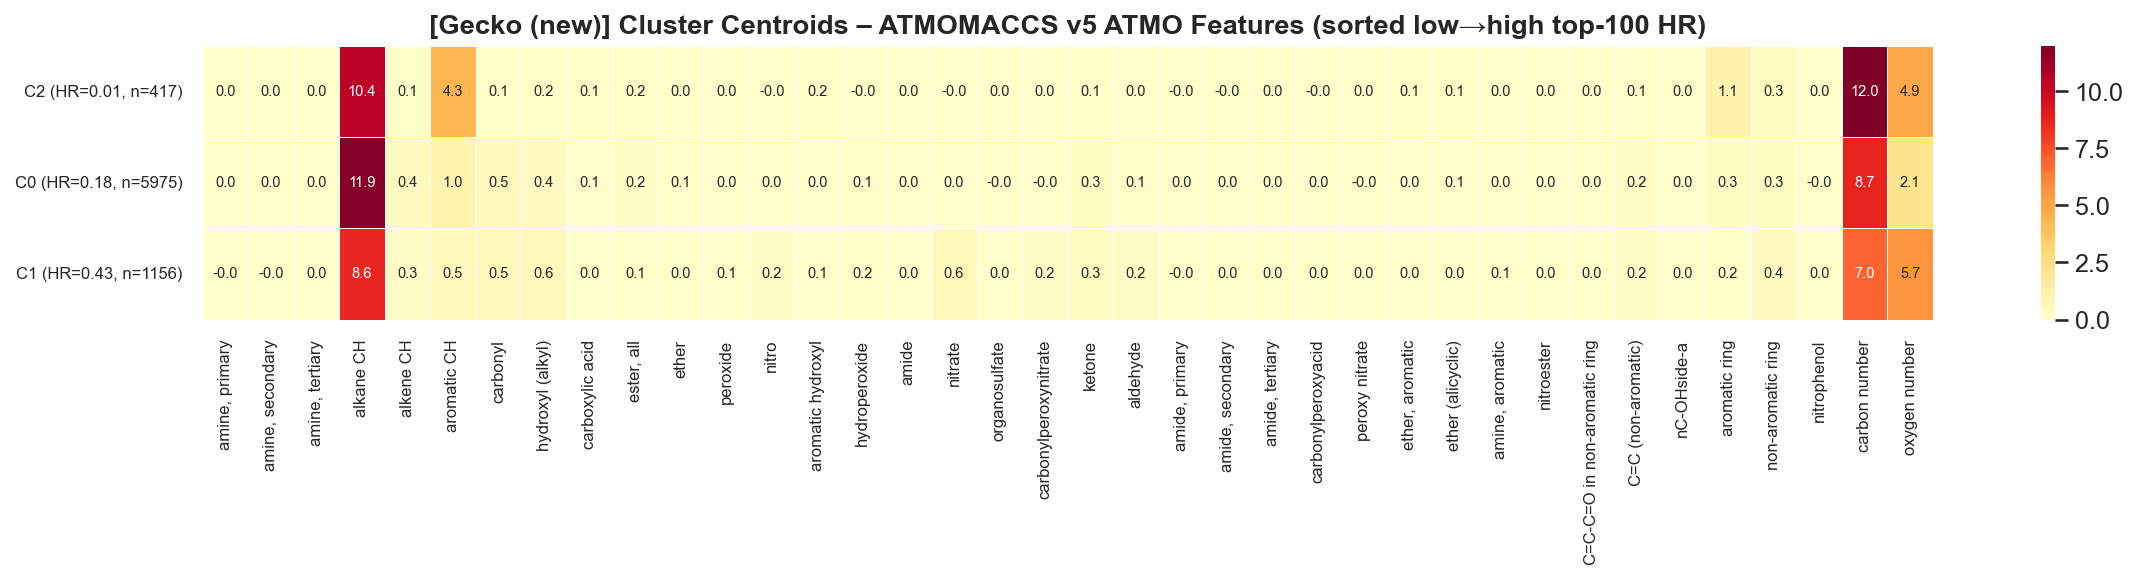


=== Gecko (new) + mixed augment (n clusters=3) ===


,n,hit_rate_top1,hit_rate_top3,hit_rate_top5,hit_rate_top10,hit_rate_top20,hit_rate_top50,hit_rate_top100,MW_mean,nC_mean,nO_mean,ArRings_mean,Fsp3_mean
cluster,,,,,,,,,,,,,
2,417,0.074,0.127,0.153,0.173,0.192,0.218,0.235,285.446,11.971,4.918,1.110,0.486
0,5975,0.055,0.108,0.140,0.184,0.233,0.287,0.308,166.524,8.715,2.059,0.288,0.665
1,1156,0.128,0.248,0.298,0.361,0.406,0.458,0.480,204.409,6.968,5.659,0.186,0.675


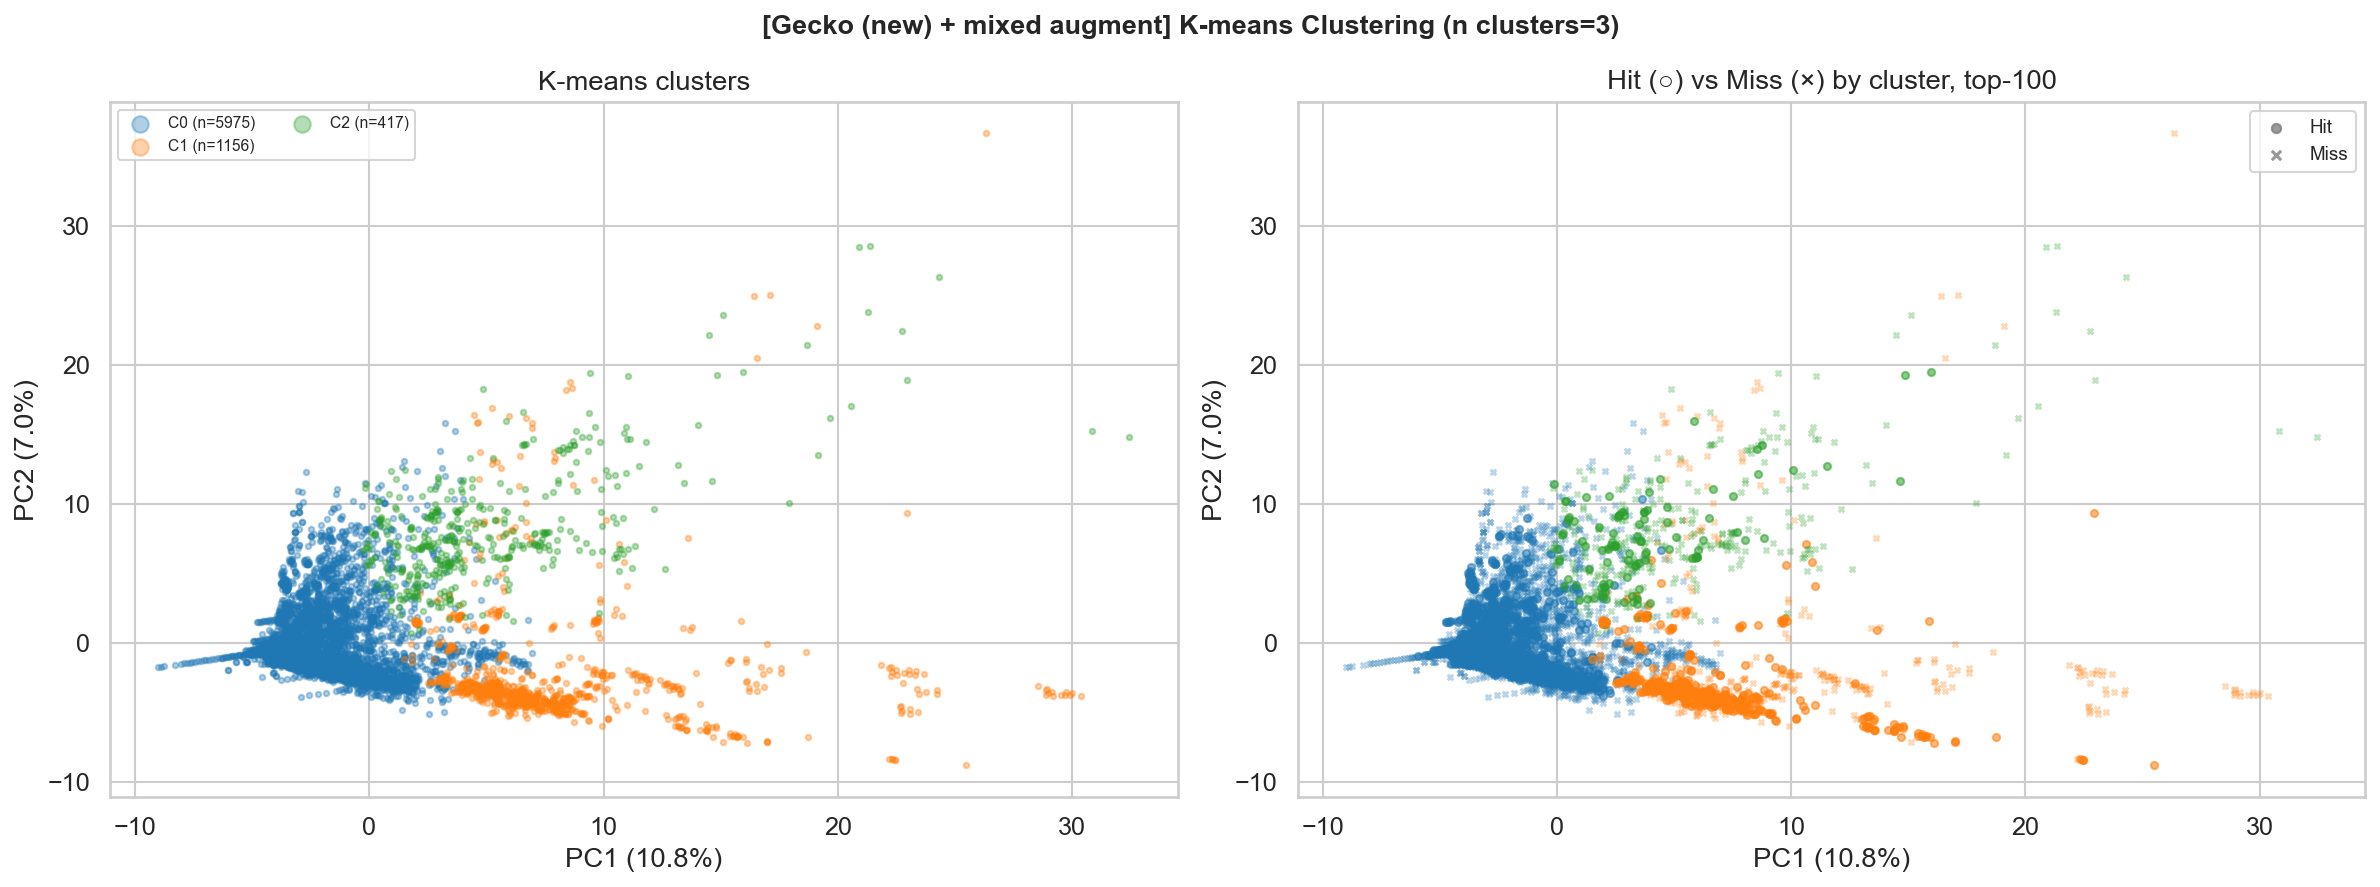

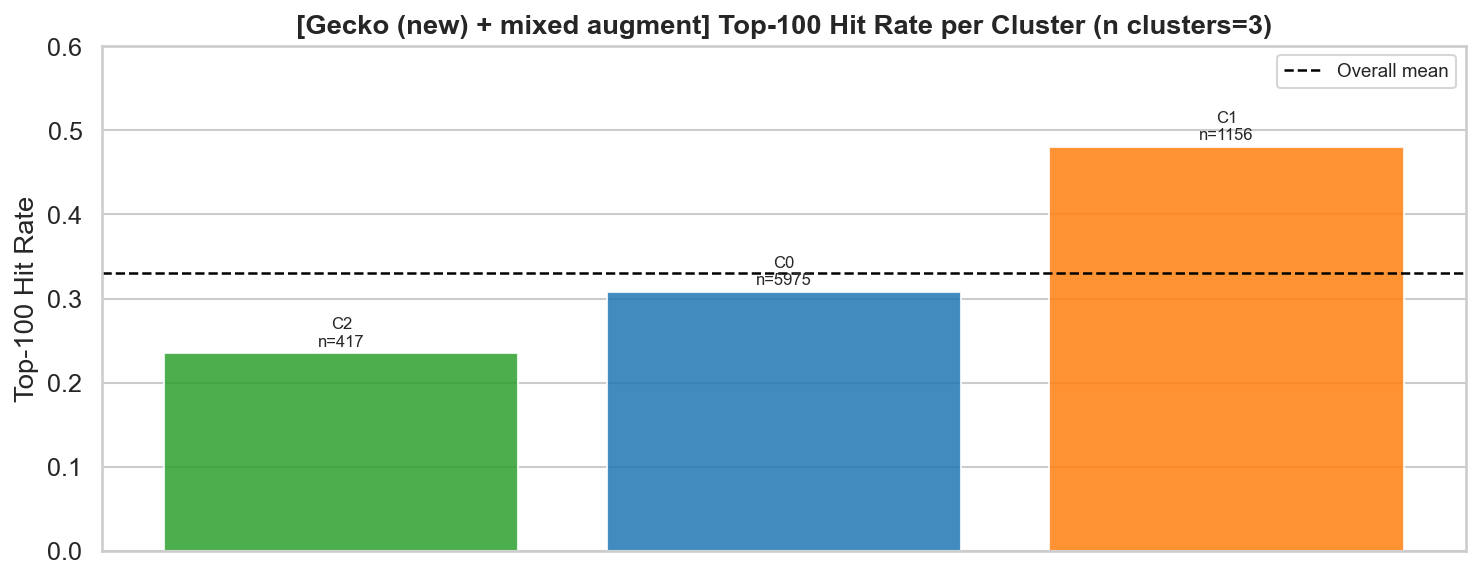

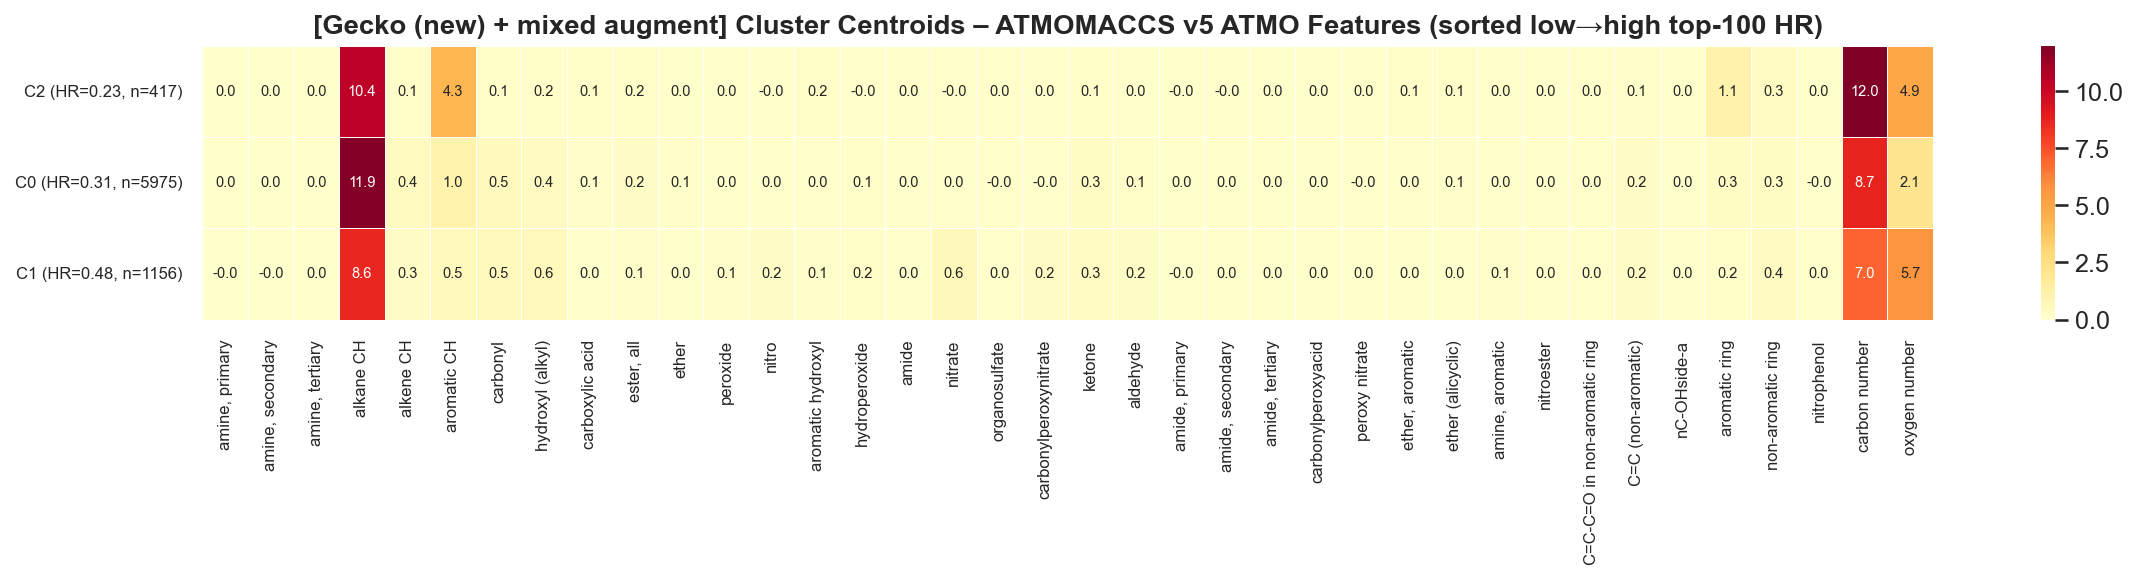

In [16]:
# Override the cluster count per experiment here if needed.
exp_best_k['Gecko (new)'] = 3
exp_best_k['Gecko (new) + mixed augment'] = 3

exp_kmeans_results = {}  # {exp_name: {'cluster_labels', 'cluster_summary', 'palette', 'K', 'km'}}
for exp_name, adf in exp_dfs.items():
    K         = exp_best_k[exp_name]
    fp_scaled = exp_pca_results[exp_name]['fp_scaled']
    pcs       = exp_pca_results[exp_name]['pcs']
    pca       = exp_pca_results[exp_name]['pca']
    scaler    = exp_pca_results[exp_name]['scaler']
    hit_mask  = adf[HIT].values
    palette   = sns.color_palette('tab10', K)

    km_final       = KMeans(n_clusters=K, n_init=20, random_state=42, max_iter=500)
    cluster_labels = km_final.fit_predict(fp_scaled)
    adf = adf.copy()
    adf['cluster'] = cluster_labels
    exp_dfs[exp_name] = adf  # update with cluster column

    agg = {'n': (HIT, 'count')}
    agg.update({f'hit_rate_top{k}': (f'hit_top{k}', 'mean') for k in K_REPORT})
    agg.update({
        'MW_mean':      ('MW', 'mean'),
        'nC_mean':      ('nC', 'mean'),
        'nO_mean':      ('nO', 'mean'),
        'ArRings_mean': ('ArRings', 'mean'),
        'Fsp3_mean':    ('Fsp3', 'mean'),
    })
    cluster_summary = adf.groupby('cluster').agg(**agg).round(3)
    HR = f'hit_rate_top{TOP_K}'

    exp_kmeans_results[exp_name] = {
        'cluster_labels': cluster_labels, 'cluster_summary': cluster_summary,
        'palette': palette, 'K': K, 'km': km_final,
    }

    print(f'\n=== {exp_name} (n clusters={K}) ===')
    display(cluster_summary.sort_values(HR))

    # Cluster scatter + hit/miss markers
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=PLOT_DPI)
    ax = axes[0]
    for c in range(K):
        m = cluster_labels == c
        ax.scatter(pcs[m, 0], pcs[m, 1], color=palette[c], alpha=0.35, s=7,
                   label=f'C{c} (n={m.sum()})', rasterized=True)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title('K-means clusters')
    ax.legend(markerscale=3, fontsize=7.5, ncol=2)

    ax2 = axes[1]
    for c in range(K):
        c_m = cluster_labels == c
        ax2.scatter(pcs[c_m & ~hit_mask, 0], pcs[c_m & ~hit_mask, 1],
                    color=palette[c], alpha=0.3, s=7, marker='x', rasterized=True)
        ax2.scatter(pcs[c_m &  hit_mask, 0], pcs[c_m &  hit_mask, 1],
                    color=palette[c], alpha=0.55, s=12, marker='o', rasterized=True)
    ax2.legend(handles=[
        plt.scatter([], [], marker='o', color='gray', s=20, label='Hit',  alpha=0.8),
        plt.scatter([], [], marker='x', color='gray', s=20, label='Miss', alpha=0.8),
    ], fontsize=9)
    ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax2.set_title(f'Hit (○) vs Miss (×) by cluster, top-{TOP_K}')
    fig.suptitle(f'[{exp_name}] K-means Clustering (n clusters={K})', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Hit rate per cluster bar chart
    cs = cluster_summary.sort_values(HR).reset_index()
    fig, ax = plt.subplots(figsize=(10, 4), dpi=PLOT_DPI)
    bars = ax.bar(cs.index, cs[HR],
                  color=[palette[c] for c in cs['cluster']], alpha=0.85, edgecolor='white')
    for bar, (_, row) in zip(bars, cs.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'C{int(row["cluster"])}\nn={int(row["n"])}',
                ha='center', va='bottom', fontsize=8)
    ax.axhline(adf[HIT].mean(), color='black', linestyle='--', linewidth=1.2, label='Overall mean')
    ax.set_ylabel(f'Top-{TOP_K} Hit Rate'); ax.set_xticks([])
    ax.set_title(f'[{exp_name}] Top-{TOP_K} Hit Rate per Cluster (n clusters={K})', fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(0, min(1.0, max(cs[HR].max() * 1.25, 1e-3)))
    plt.tight_layout(); plt.show()

    # Centroid heatmap (ATMO features only)
    centroids_orig = scaler.inverse_transform(km_final.cluster_centers_)
    centroid_df    = pd.DataFrame(centroids_orig, columns=atmomaccs_feat_names)
    hr_order       = cluster_summary[HR].sort_values().index.tolist()
    labels_sorted  = [f'C{c} (HR={cluster_summary.loc[c, HR]:.2f}, n={int(cluster_summary.loc[c,"n"])})'
                      for c in hr_order]
    fig, ax = plt.subplots(figsize=(16, max(4, K * 0.6 + 1)), dpi=PLOT_DPI)
    sns.heatmap(centroid_df[atmo_feat_names].loc[hr_order], ax=ax,
                yticklabels=labels_sorted, xticklabels=atmo_feat_names,
                cmap='YlOrRd', linewidths=0.3, annot=True, fmt='.1f', annot_kws={'size': 7})
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    ax.set_title(f'[{exp_name}] Cluster Centroids – ATMOMACCS v5 ATMO Features '
                 f'(sorted low→high top-{TOP_K} HR)', fontweight='bold')
    plt.tight_layout(); plt.show()

## 8. Hardest and easiest clusters — representative molecule inspection


=== Gecko (new) (top-100) ===
Hardest cluster: C2  (hit rate = 0.007)  — showing misses


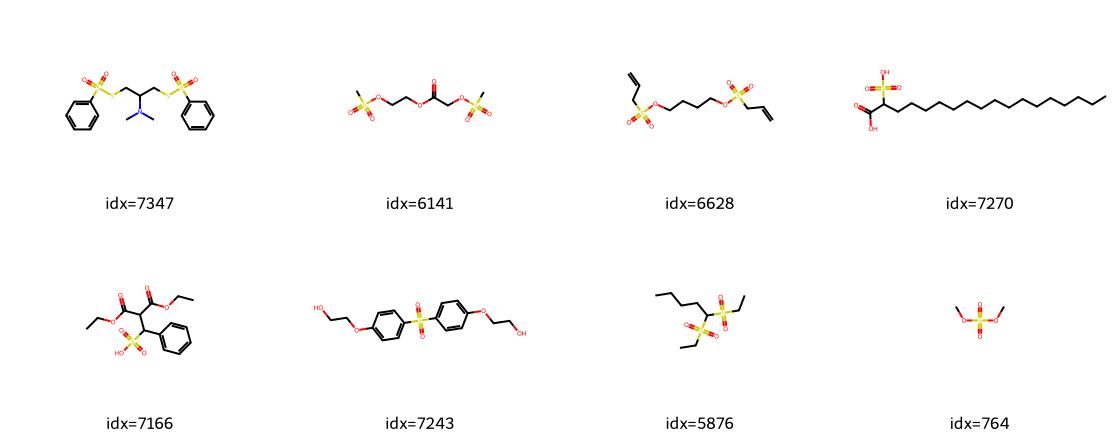

Easiest cluster: C1  (hit rate = 0.435)  — showing hits


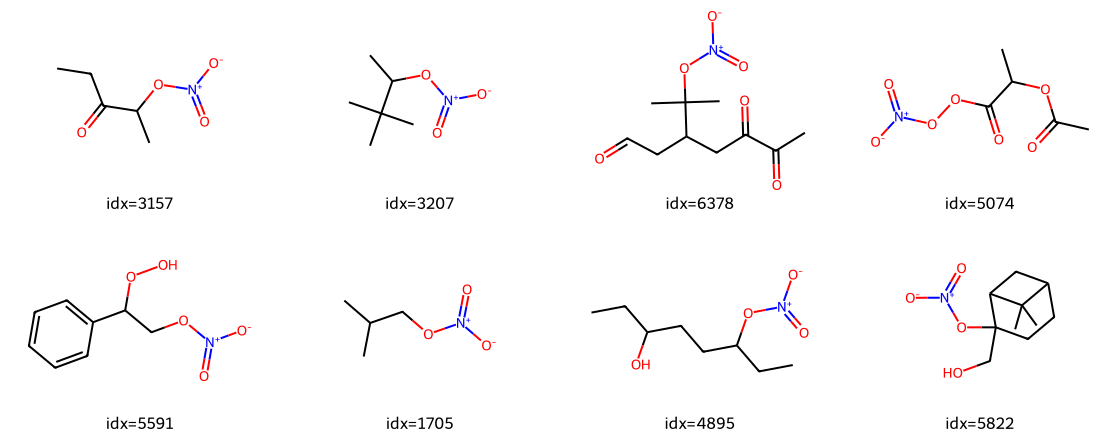


=== Gecko (new) + mixed augment (top-100) ===
Hardest cluster: C2  (hit rate = 0.235)  — showing misses


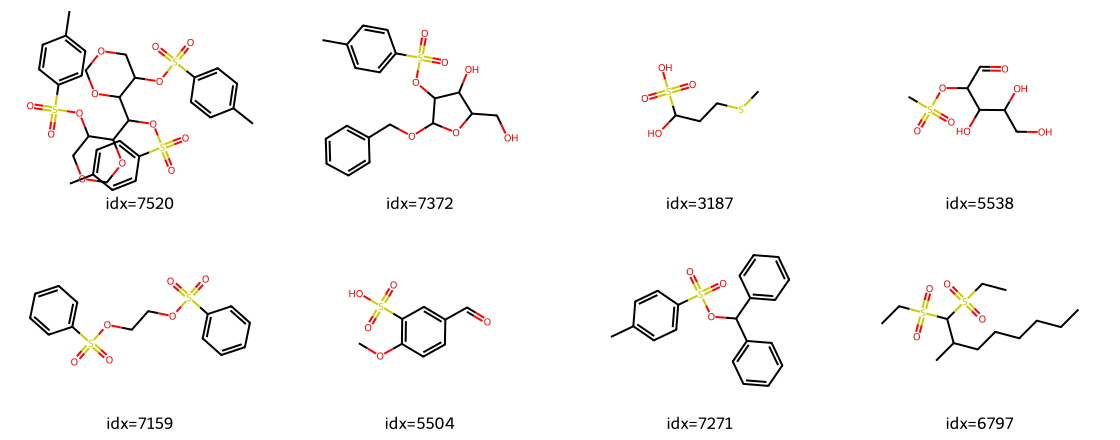

Easiest cluster: C1  (hit rate = 0.480)  — showing hits


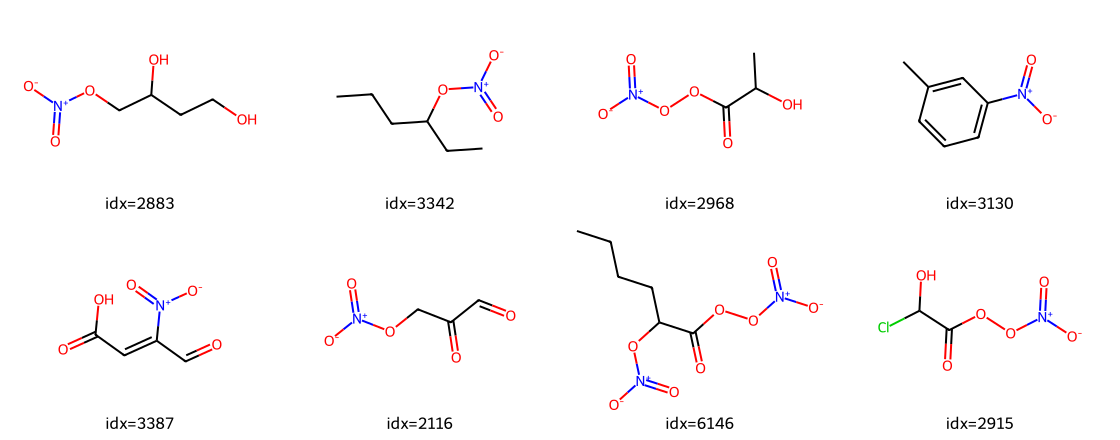

In [17]:
def draw_mols_from_cluster(adf, records, cluster_id, hit_filter, n=8):
    idx = adf.index[(adf['cluster'] == cluster_id) & (adf[HIT] == hit_filter)].tolist()
    if not idx:
        print('  No molecules found.')
        return None
    np.random.seed(0)
    idx = np.random.choice(idx, min(n, len(idx)), replace=False)
    mols = [records[i]['true_mol'] for i in idx]
    return Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(280, 220),
                                legends=[f'idx={i}' for i in idx])

for exp_name, adf in exp_dfs.items():
    km_res  = exp_kmeans_results[exp_name]
    cs      = km_res['cluster_summary']
    records = experiments_records[exp_name]
    HR      = f'hit_rate_top{TOP_K}'

    hardest = cs[HR].idxmin()
    easiest = cs[HR].idxmax()

    print(f'\n=== {exp_name} (top-{TOP_K}) ===')
    print(f'Hardest cluster: C{hardest}  (hit rate = {cs.loc[hardest, HR]:.3f})  — showing misses')
    img = draw_mols_from_cluster(adf, records, hardest, hit_filter=False)
    if img: display(img)

    print(f'Easiest cluster: C{easiest}  (hit rate = {cs.loc[easiest, HR]:.3f})  — showing hits')
    img = draw_mols_from_cluster(adf, records, easiest, hit_filter=True)
    if img: display(img)

## 9. Summary: top predictors of difficulty

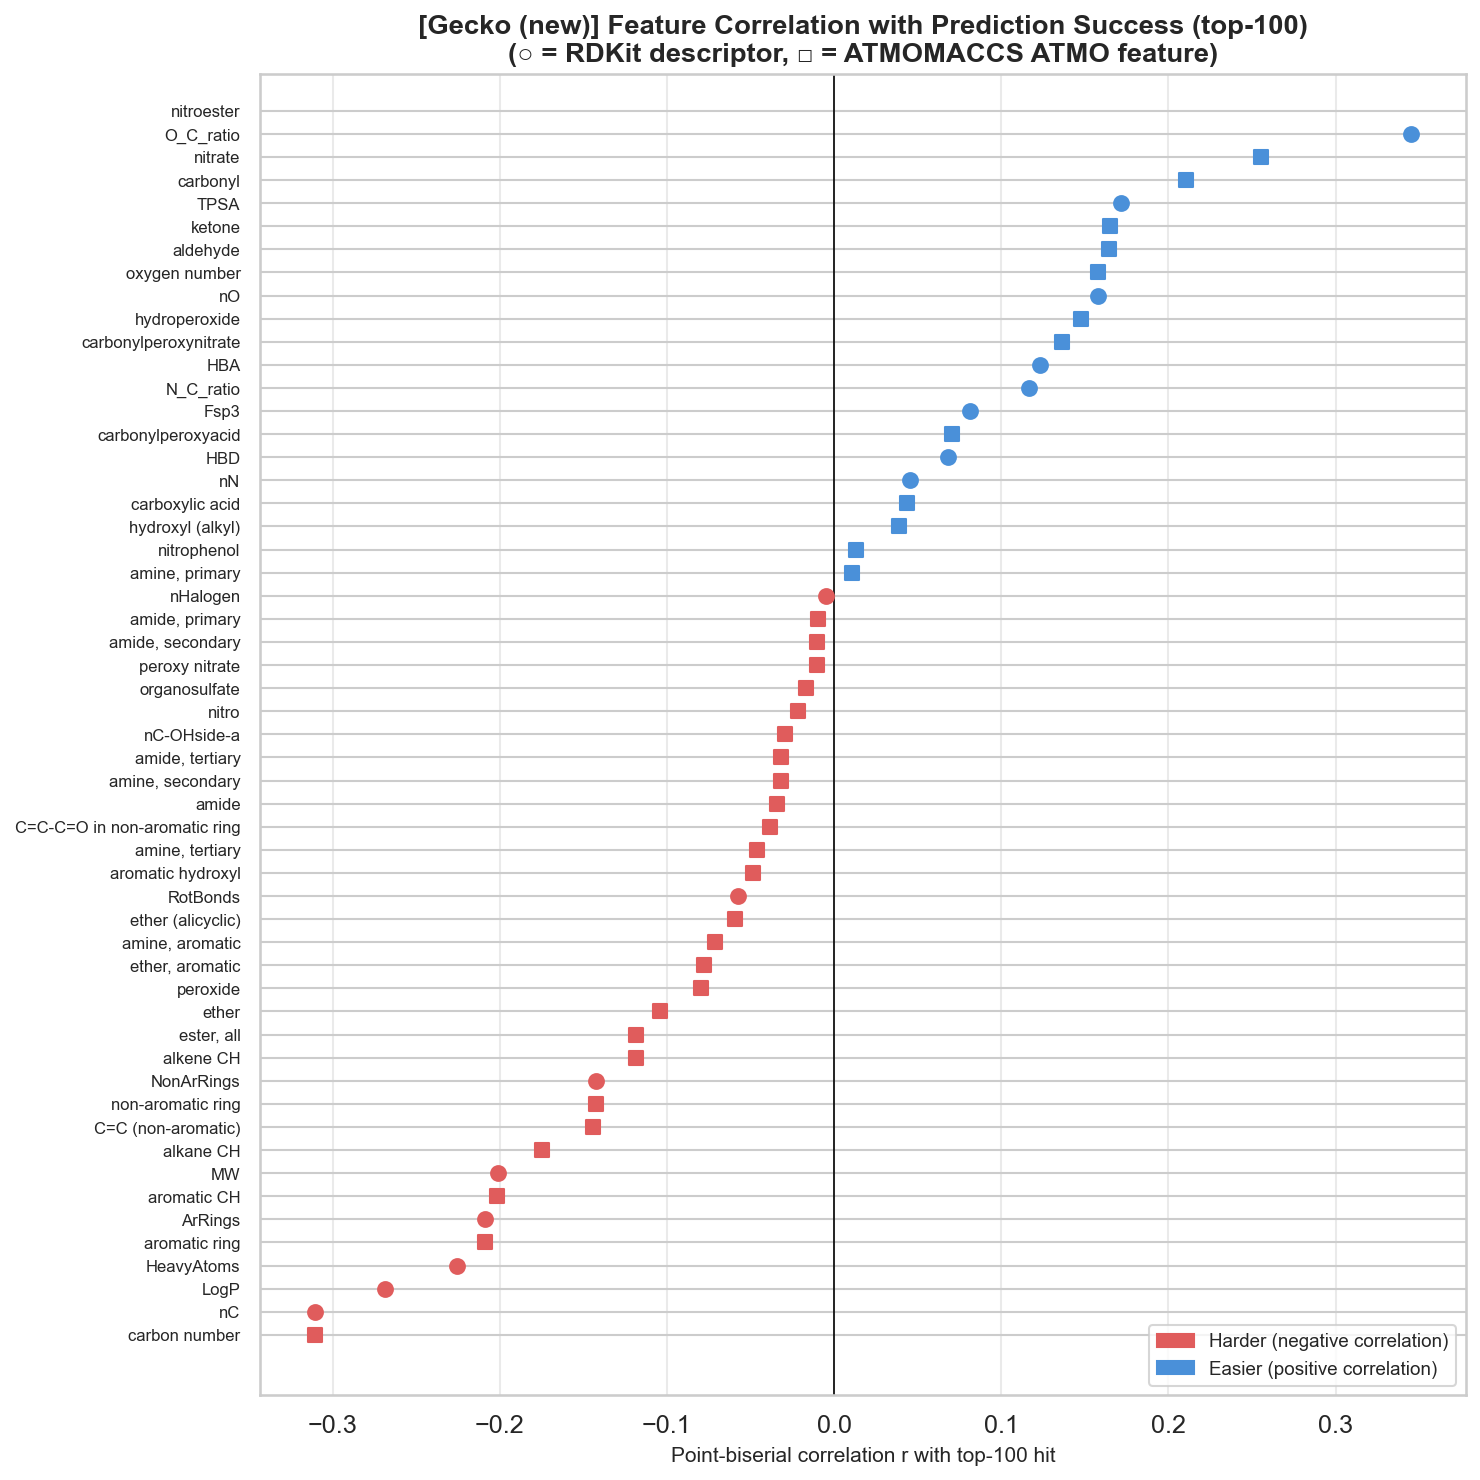


=== Gecko (new) — top negative correlates (hardest features) ===


,Feature,type,r_pb,p-value
52,carbon number,ATMO,-0.3104,0.0
10,nC,descriptor,-0.3104,0.0
1,LogP,descriptor,-0.2689,0.0
9,HeavyAtoms,descriptor,-0.2256,0.0
49,aromatic ring,ATMO,-0.2090,0.0
6,ArRings,descriptor,-0.2090,0.0
21,aromatic CH,ATMO,-0.2018,0.0
0,MW,descriptor,-0.2009,0.0
19,alkane CH,ATMO,-0.1746,0.0
47,C=C (non-aromatic),ATMO,-0.1441,0.0



=== Gecko (new) — top positive correlates (easiest features) ===


,Feature,type,r_pb,p-value
34,carbonylperoxynitrate,ATMO,0.1364,0.0
30,hydroperoxide,ATMO,0.1479,0.0
11,nO,descriptor,0.1581,0.0
53,oxygen number,ATMO,0.1581,0.0
36,aldehyde,ATMO,0.1642,0.0
35,ketone,ATMO,0.1653,0.0
2,TPSA,descriptor,0.1716,0.0
22,carbonyl,ATMO,0.2102,0.0
32,nitrate,ATMO,0.2554,0.0
14,O_C_ratio,descriptor,0.3449,0.0


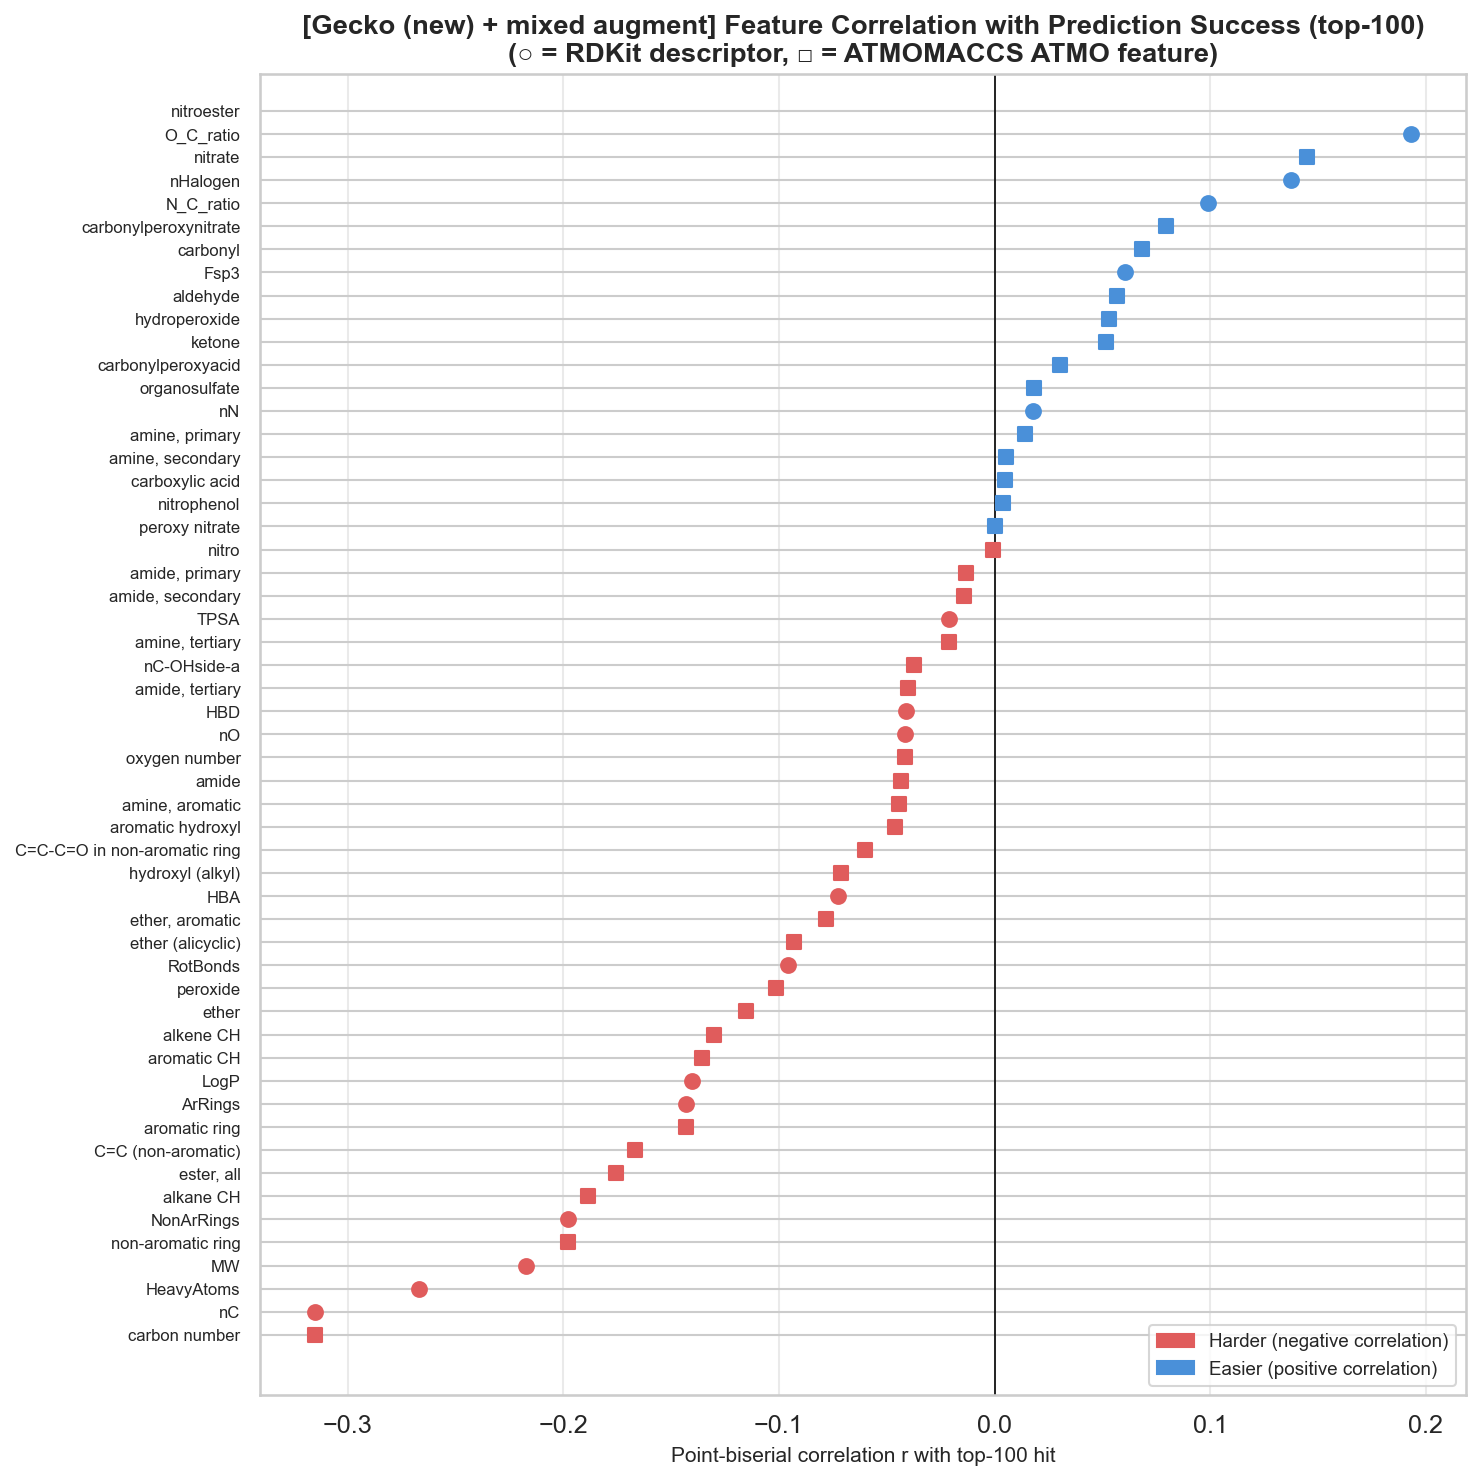


=== Gecko (new) + mixed augment — top negative correlates (hardest features) ===


,Feature,type,r_pb,p-value
52,carbon number,ATMO,-0.3152,0.0
10,nC,descriptor,-0.3152,0.0
9,HeavyAtoms,descriptor,-0.2669,0.0
0,MW,descriptor,-0.2172,0.0
50,non-aromatic ring,ATMO,-0.1978,0.0
7,NonArRings,descriptor,-0.1978,0.0
19,alkane CH,ATMO,-0.1888,0.0
25,"ester, all",ATMO,-0.1754,0.0
47,C=C (non-aromatic),ATMO,-0.1667,0.0
49,aromatic ring,ATMO,-0.1431,0.0



=== Gecko (new) + mixed augment — top positive correlates (easiest features) ===


,Feature,type,r_pb,p-value
35,ketone,ATMO,0.0518,0.0
30,hydroperoxide,ATMO,0.0533,0.0
36,aldehyde,ATMO,0.0568,0.0
8,Fsp3,descriptor,0.0607,0.0
22,carbonyl,ATMO,0.0685,0.0
34,carbonylperoxynitrate,ATMO,0.0797,0.0
15,N_C_ratio,descriptor,0.0992,0.0
13,nHalogen,descriptor,0.1375,0.0
32,nitrate,ATMO,0.1448,0.0
14,O_C_ratio,descriptor,0.1931,0.0


In [18]:
exp_corr_dfs = {}

for exp_name, adf in exp_dfs.items():
    hit_label = adf[HIT].astype(float).values
    corr_rows = []
    for feat in desc_cols + atmo_feat_names:
        vals = adf[feat].fillna(0).values.astype(float)
        r, pval = stats.pointbiserialr(hit_label, vals)
        corr_rows.append({'Feature': feat, 'r_pb': r, 'p-value': pval,
                          'type': 'descriptor' if feat in desc_cols else 'ATMO'})

    corr_df = pd.DataFrame(corr_rows).sort_values('r_pb')
    exp_corr_dfs[exp_name] = corr_df

    fig, ax = plt.subplots(figsize=(10, 10), dpi=PLOT_DPI)
    for i, (_, row) in enumerate(corr_df.iterrows()):
        ax.scatter(row['r_pb'], i,
                   color=('#e05c5c' if row['r_pb'] < 0 else '#4a90d9'),
                   marker='o' if row['type'] == 'descriptor' else 's', s=50, zorder=3)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(range(len(corr_df)))
    ax.set_yticklabels(corr_df['Feature'], fontsize=8)
    ax.set_xlabel(f'Point-biserial correlation r with top-{TOP_K} hit', fontsize=10)
    ax.set_title(f'[{exp_name}] Feature Correlation with Prediction Success (top-{TOP_K})\n'
                 f'(○ = RDKit descriptor, □ = ATMOMACCS ATMO feature)', fontweight='bold')
    ax.grid(axis='x', alpha=0.4)
    ax.legend(handles=[
        mpatches.Patch(color='#e05c5c', label='Harder (negative correlation)'),
        mpatches.Patch(color='#4a90d9', label='Easier (positive correlation)'),
    ], loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.show()

    print(f'\n=== {exp_name} — top negative correlates (hardest features) ===')
    display(corr_df[corr_df['r_pb'] < 0].head(15)[['Feature', 'type', 'r_pb', 'p-value']].round(4))
    print(f'\n=== {exp_name} — top positive correlates (easiest features) ===')
    display(corr_df[corr_df['r_pb'] > 0].tail(10)[['Feature', 'type', 'r_pb', 'p-value']].round(4))

In [19]:
# Output filenames carry TOP_K so runs at different k do not overwrite each other.
for exp_name in exp_dfs:
    stem = f'results_top{TOP_K}_{slug(exp_name)}'
    exp_corr_dfs[exp_name].to_csv(f'{stem}_feature_difficulty.csv', index=False)
    exp_kmeans_results[exp_name]['cluster_summary'].to_csv(f'{stem}_cluster_summary.csv')
    print(f'Saved {stem}_feature_difficulty.csv and {stem}_cluster_summary.csv')

acc_df.to_csv(f'results_top{TOP_K}_accuracy.csv')
print(f'Saved results_top{TOP_K}_accuracy.csv')

Saved results_top100_Gecko_new_feature_difficulty.csv and results_top100_Gecko_new_cluster_summary.csv
Saved results_top100_Gecko_new_mixed_augment_feature_difficulty.csv and results_top100_Gecko_new_mixed_augment_cluster_summary.csv
Saved results_top100_accuracy.csv
